In [12]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from os import getcwd, listdir
import missingno as msno
import re
import plotly.express as px
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
getcwd()

'C:\\Users\\AmiranBehine.com'

In [3]:
# Portable repository paths are configured above; no local chdir needed.
warnings.filterwarnings("ignore")

In [4]:
df_main=pd.read_csv(DATA_RAW / "divar_real_estate_ads.csv")
df=df_main.copy()

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.0f}'.format)
df

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_to_single,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500,NaN,NaN,NaN,سه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,6,"350,000","1,500,000","3,500,000,000","3,500,000",36,51,500
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,NaN,NaN,مقطوع,"8,500,000,000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60,NaN,NaN,3,یک,NaN,NaN,NaN,True,True,True,۱۳۸۴,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,"26,000,000",NaN,NaN,NaN,NaN,مقطوع,"750,000,000",False,False,"750,000,000",NaN,"26,000,000",NaN,NaN,132,NaN,NaN,3,سه,NaN,NaN,NaN,True,True,True,۱۴۰۱,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36,51,NaN
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,"95,000,000",NaN,NaN,NaN,NaN,مقطوع,"950,000,000",False,False,"950,000,000",NaN,"95,000,000",NaN,NaN,90,NaN,NaN,4,یک,NaN,NaN,NaN,True,False,True,۱۴۰۰,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,NaN,NaN,مقطوع,"5,750,000,000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115,single_page,NaN,4,دو,6,NaN,true,True,True,True,۱۴۰۳,NaN,NaN,package,NaN,NaN,shoofaj,air_conditioner,squat_seat,NaN,NaN,north,NaN,NaN,NaN,ceramic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,residential-sell,apartment-sell,kermanshah,NaN,2024-07-01 00:00:00,مشاور املاک,~~~مشاورین املاک قبادی~~~\n■جنوبی تک واحدی\n■د...,آپارتمان ۱۸۰ متری وحدت غربی,NaN,NaN,NaN,NaN,مقطوع,"7,470,000,000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180,NaN,NaN,4,چهار,NaN,NaN,NaN,True,True,True,۱۴۰۳,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34,47,500
999996,residential-rent,apartment-rent,tehran,darya,2024-07-01 00:00:00,مشاور املاک,نوساز \n\n تک واحدی\n\nشخصی ساز\n\nروف گا...,آپارتمان ۱۱۰ متری سعادت آباد دریا,مقطوع,"45,000,000",NaN,rent_credit,NaN,NaN,مقطوع,"1,000,000,000",True,True,"1,000,000,000","3,000,000,000","45,000,000","100,000",NaN,110,NaN,NaN,1,دو,NaN,NaN,NaN,True,True,True,۱۴۰۳,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36,51,500
999997,residential-sell,

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 60 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   cat2_slug                   1000000 non-null  object 
 1   cat3_slug                   999999 non-null   object 
 2   city_slug                   999998 non-null   object 
 3   neighborhood_slug           437139 non-null   object 
 4   created_at_month            1000000 non-null  object 
 5   user_type                   288882 non-null   object 
 6   description                 1000000 non-null  object 
 7   title                       999946 non-null   object 
 8   rent_mode                   352994 non-null   object 
 9   rent_value                  351322 non-null   float64
 10  rent_to_single              19 non-null       object 
 11  rent_type                   103961 non-null   object 
 12  price_mode                  573606 non-null   object 
 13

In [8]:
df.describe()

,rent_value,price_value,credit_value,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,regular_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
count,3.513220e+05,5.683460e+05,3.520950e+05,3.520850e+05,7.240900e+04,3.512480e+05,7.240900e+04,1.863960e+05,9.803940e+05,29870.000000,1.024100e+04,1.806800e+04,1.046300e+04,1.355100e+04,655608.000000,655608.000000,339699.000000
mean,4.102299e+10,1.736537e+10,4.872084e+10,4.872222e+10,8.557025e+09,4.103164e+10,1.619934e+07,4.165480e+03,4.440648e+03,6.557650,1.209785e+10,1.389016e+11,2.355548e+10,3.156551e+10,34.982108,51.629743,465.149147
std,3.807534e+12,5.878739e+11,4.341346e+12,4.341407e+12,2.064576e+12,3.807935e+12,5.217890e+07,1.218927e+05,1.367118e+05,7.698655,1.103482e+12,7.042335e+12,1.542049e+12,2.434942e+12,2.379169,3.160920,125.896250
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,23.626478,40.162369,0.000000
25%,1.111110e+05,1.400000e+09,1.000000e+08,1.000000e+08,2.000000e+08,1.111110e+05,1.000000e+06,1.100000e+02,7.500000e+01,3.000000,5.000000e+04,4.000000e+05,6.000000e+05,5.500000e+05,34.553551,50.677175,500.000000
50%,5.000000e+06,2.840000e+09,2.500000e+08,2.500000e+08,4.000000e+08,5.000000e+06,6.000000e+06,1.950000e+02,1.030000e+02,4.000000,1.000000e+05,8.000000e+05,1.200000e+06,1.100000e+06,35.723312,51.345791,500.000000
75%,1.200000e+07,5.900000e+09,5.000000e+08,5.000000e+08,8.500000e+08,1.200000e+07,1.500000e+07,2.800000e+02,1.650000e+02,7.000000,2.000000e+05,1.600000e+06,2.500000e+06,2.500000e+06,36.307013,51.805291,500.000000
max,1.000000e+15,1.000000e+14,1.000000e+15,1.000000e+15,5.555556e+14,1.000000e+15,3.000000e+09,1.000000e+07,1.000000e+07,50.000000,1.111111e+14,5.006007e+14,1.111111e+14,2.002503e+14,40.358055,74.511620,500.000000


In [10]:
df.describe()

,rent_value,price_value,credit_value,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,regular_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
count,"351,322","568,346","352,095","352,085","72,409","351,248","72,409","186,396","980,394","29,870","10,241","18,068","10,463","13,551","655,608","655,608","339,699"
mean,"41,022,993,842","17,365,370,640","48,720,843,307","48,722,218,216","8,557,025,436","41,031,635,748","16,199,337","4,165","4,441",7,"12,097,853,225","138,901,595,343","23,555,479,873","31,565,505,114",35,52,465
std,"3,807,534,359,773","587,873,885,224","4,341,345,683,533","4,341,407,327,546","2,064,576,077,065","3,807,935,373,875","52,178,904","121,893","136,712",8,"1,103,481,904,299","7,042,334,684,882","1,542,048,595,012","2,434,942,028,116",2,3,126
min,0,0,0,0,0,0,0,1,1,1,0,0,0,0,24,40,0
25%,"111,111","1,400,000,000","100,000,000","100,000,000","200,000,000","111,111","1,000,000",110,75,3,"50,000","400,000","600,000","550,000",35,51,500
50%,"5,000,000","2,840,000,000","250,000,000","250,000,000","400,000,000","5,000,000","6,000,000",195,103,4,"100,000","800,000","1,200,000","1,100,000",36,51,500
75%,"12,000,000","5,900,000,000","500,000,000","500,000,000","850,000,000","12,000,000","15,000,000",280,165,7,"200,000","1,600,000","2,500,000","2,500,000",36,52,500
max,"999,999,999,999,999","99,999,999,999,999","999,999,999,999,999","999,999,999,999,999","555,555,555,555,555","999,999,999,999,999","3,000,000,000","10,000,000","10,000,000",50,"111,111,111,111,111","500,600,700,800,900","111,111,111,111,111","200,250,300,400,450",40,75,500


In [9]:
df.dtypes


cat2_slug                      object
cat3_slug                      object
city_slug                      object
neighborhood_slug              object
created_at_month               object
user_type                      object
description                    object
title                          object
rent_mode                      object
rent_value                    float64
rent_to_single                 object
rent_type                      object
price_mode                     object
price_value                   float64
credit_mode                    object
credit_value                  float64
rent_credit_transform          object
transformable_price            object
transformable_credit          float64
transformed_credit            float64
transformable_rent            float64
transformed_rent              float64
land_size                     float64
building_size                 float64
deed_type                      object
has_business_deed              object
floor       

In [11]:
df.cat2_slug.value_counts()

cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64

In [12]:
df.columns

Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_value', 'rent_to_single', 'rent_type', 'price_mode',
       'price_value', 'credit_mode', 'credit_value', 'rent_credit_transform',
       'transformable_price', 'transformable_credit', 'transformed_credit',
       'transformable_rent', 'transformed_rent', 'land_size', 'building_size',
       'deed_type', 'has_business_deed', 'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',
       'regular_person_capacity', 'extra_person

## بررسی کیفیت داده
1. مقادیر ناموجود در هر یک از ستون‌ها را بررسی و ستون‌ها و ردیف‌هایی که مقادیر موجود بیشتری دارند را مشخص کنید.

In [13]:
nan_cols = (df.isna().mean() * 100).sort_values(ascending=False)

nan_rows = (df.isna().mean(axis=1) * 100).sort_values(ascending=False)

print(nan_cols.head(30))
print(nan_rows.head(30))

rent_to_single                99.9981
cost_per_extra_person         98.9759
rent_price_on_special_days    98.9537
rent_price_at_weekends        98.6449
rent_price_on_regular_days    98.1932
extra_person_capacity         97.5991
property_type                 97.2943
has_sauna                     97.1521
has_jacuzzi                   97.1272
has_pool                      97.0610
regular_person_capacity       97.0130
has_barbecue                  96.8802
has_security_guard            96.8688
has_gas                       96.6570
has_water                     96.6556
has_electricity               96.6555
has_business_deed             96.5321
transformed_credit            92.7591
transformed_rent              92.7591
rent_type                     89.6039
land_size                     81.3604
deed_type                     74.6542
user_type                     71.1118
unit_per_floor                69.7717
total_floors_count            69.5648
building_direction            67.6077
location_rad

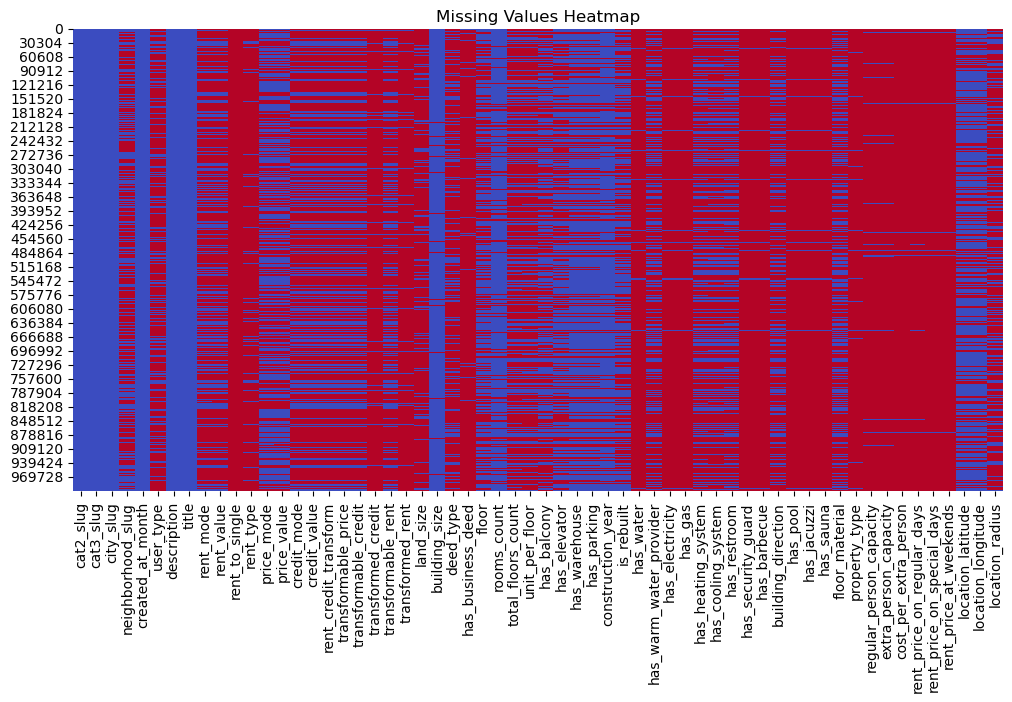

In [14]:


plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cbar=False, cmap="coolwarm")
#sns.heatmap(df.isna(), cbar=False, cmap="coolwarm")

plt.title("Missing Values Heatmap")
plt.show()


In [106]:
!pip install missingno

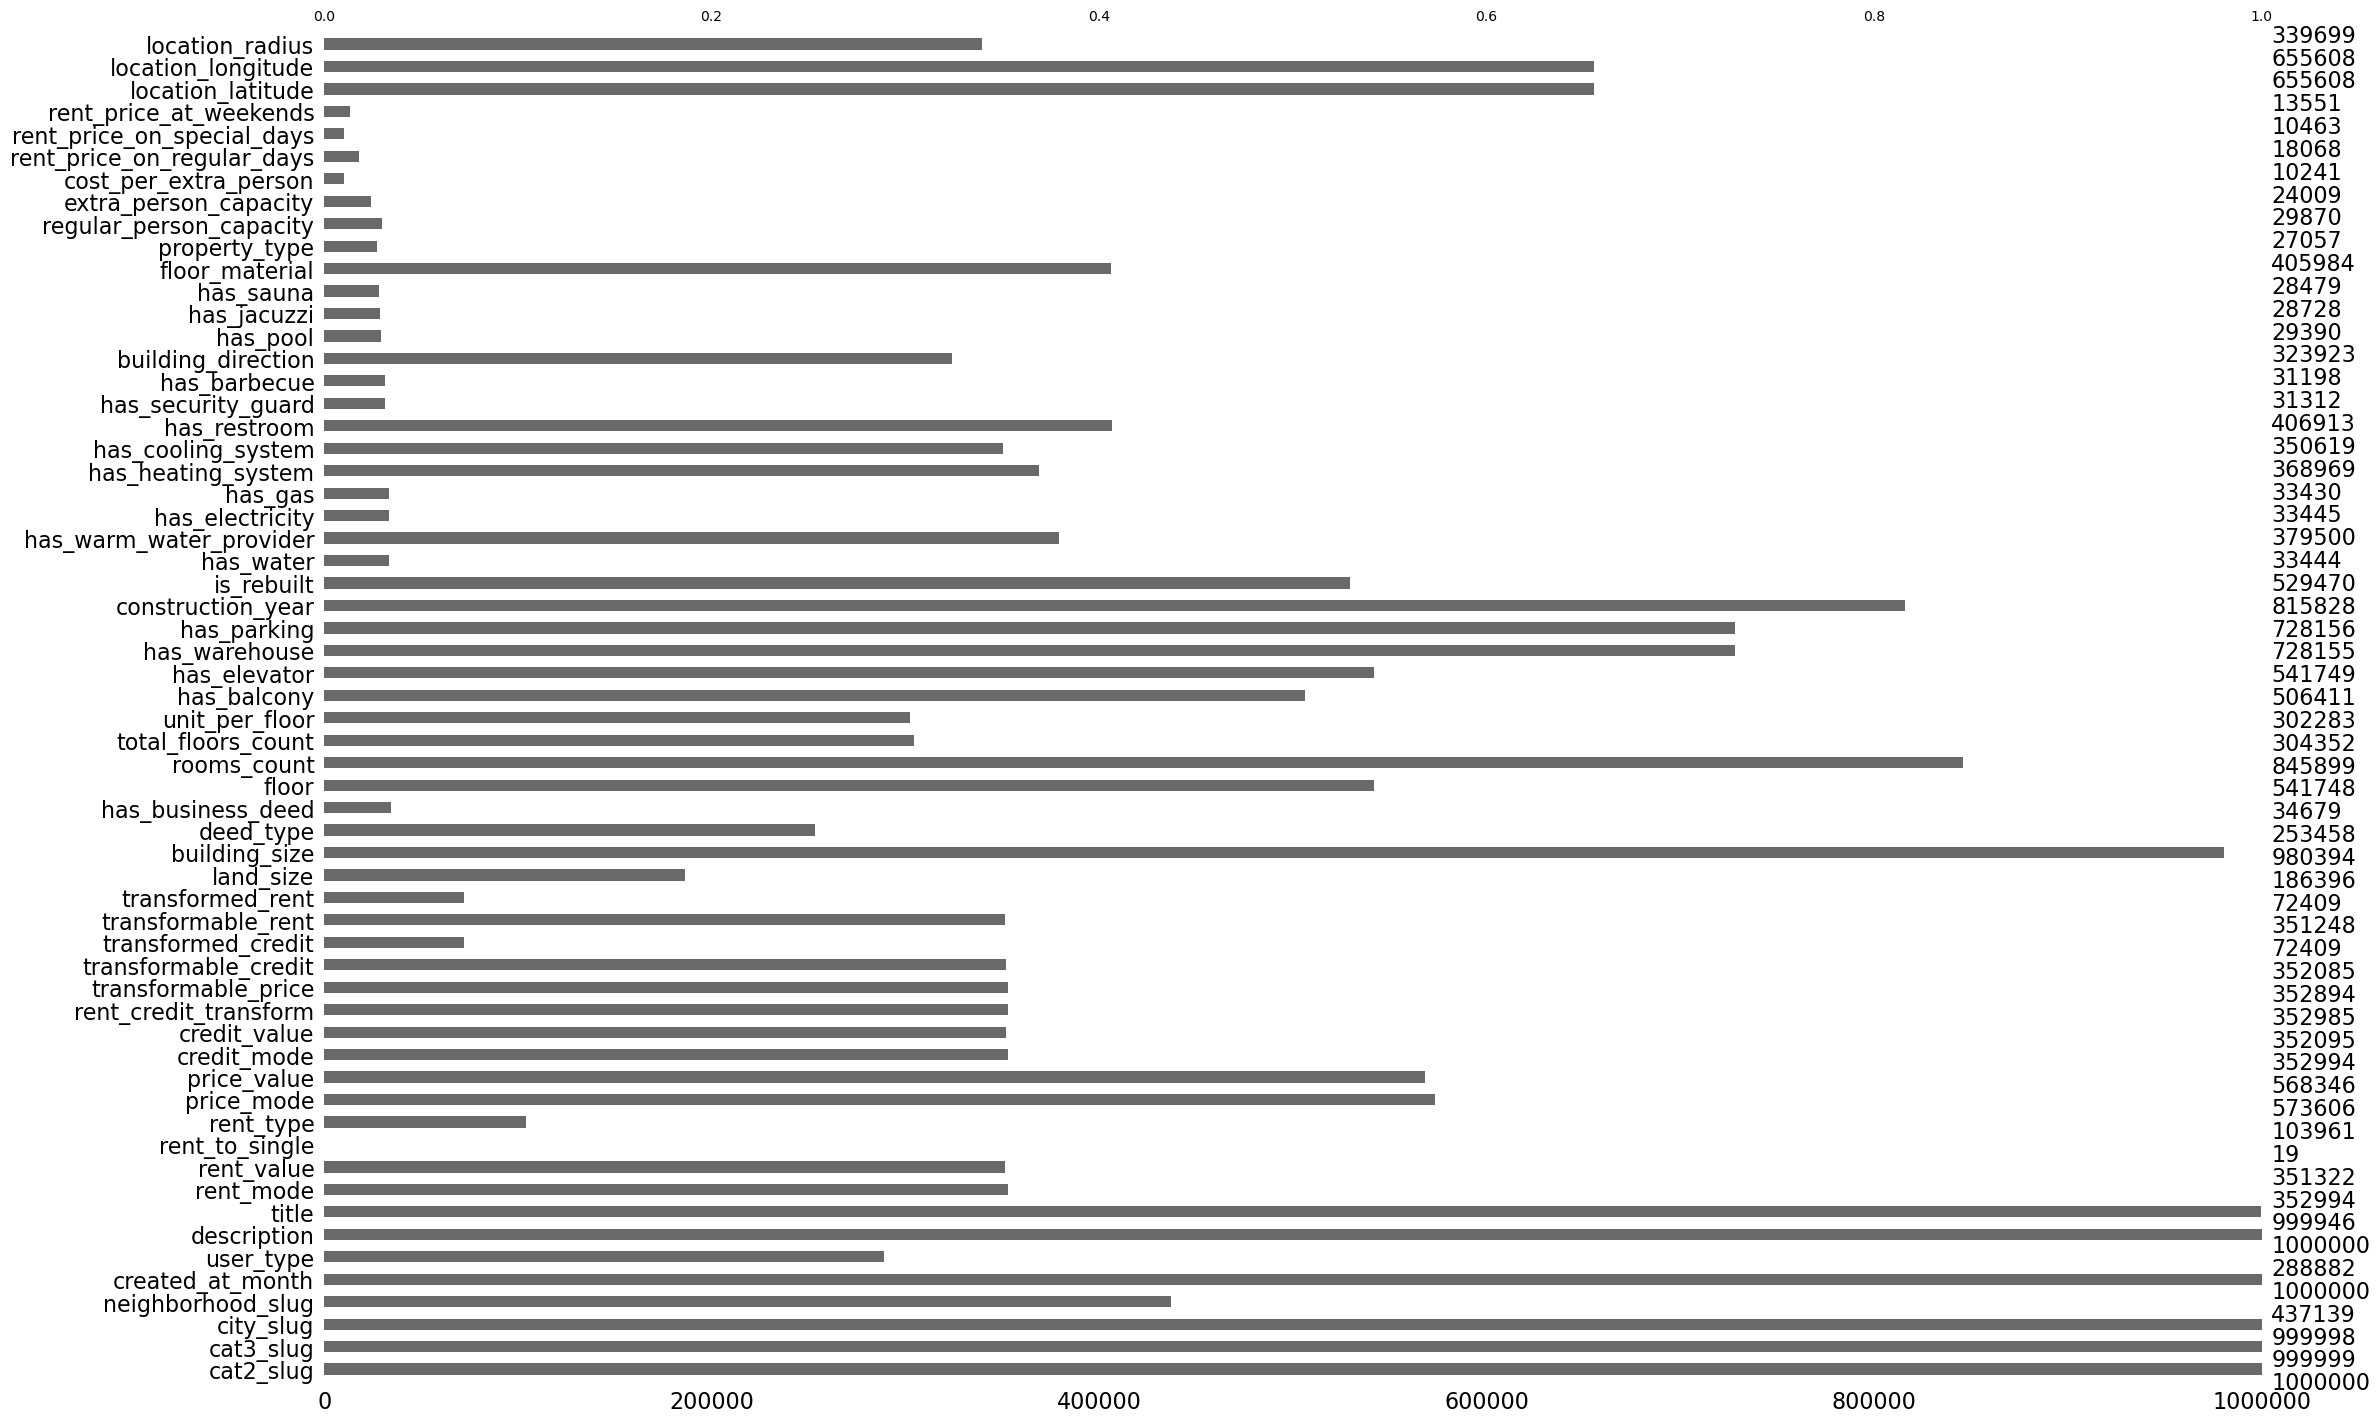

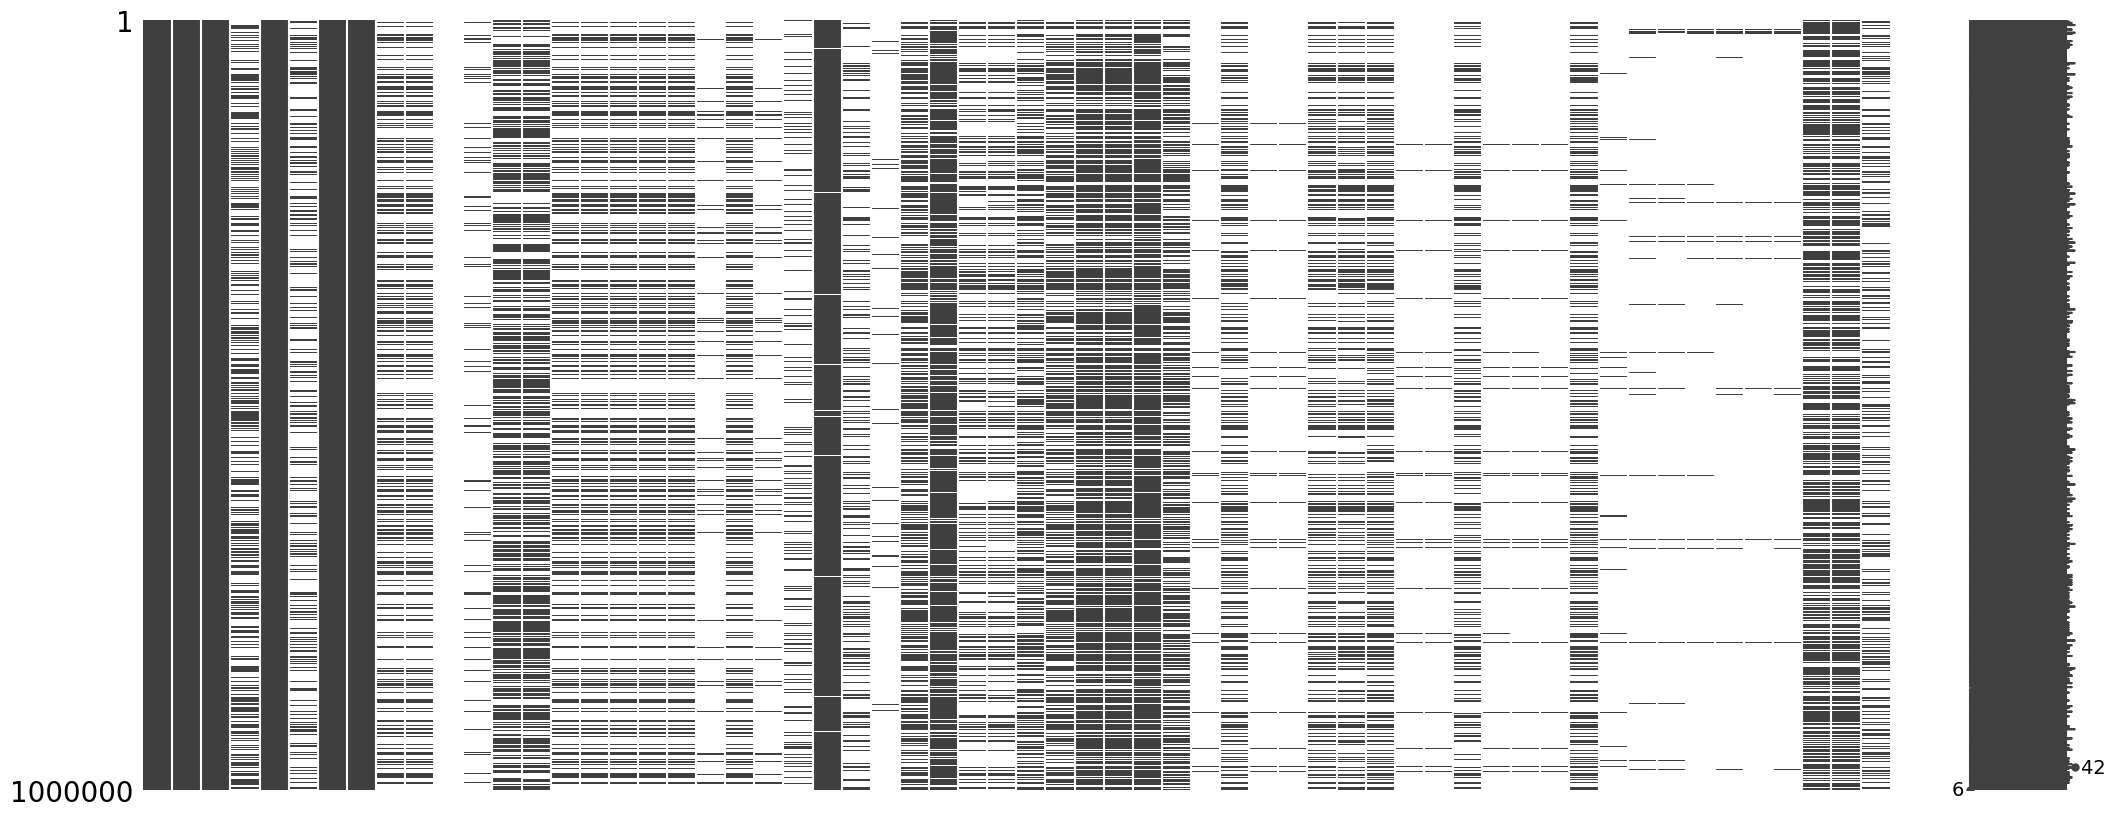

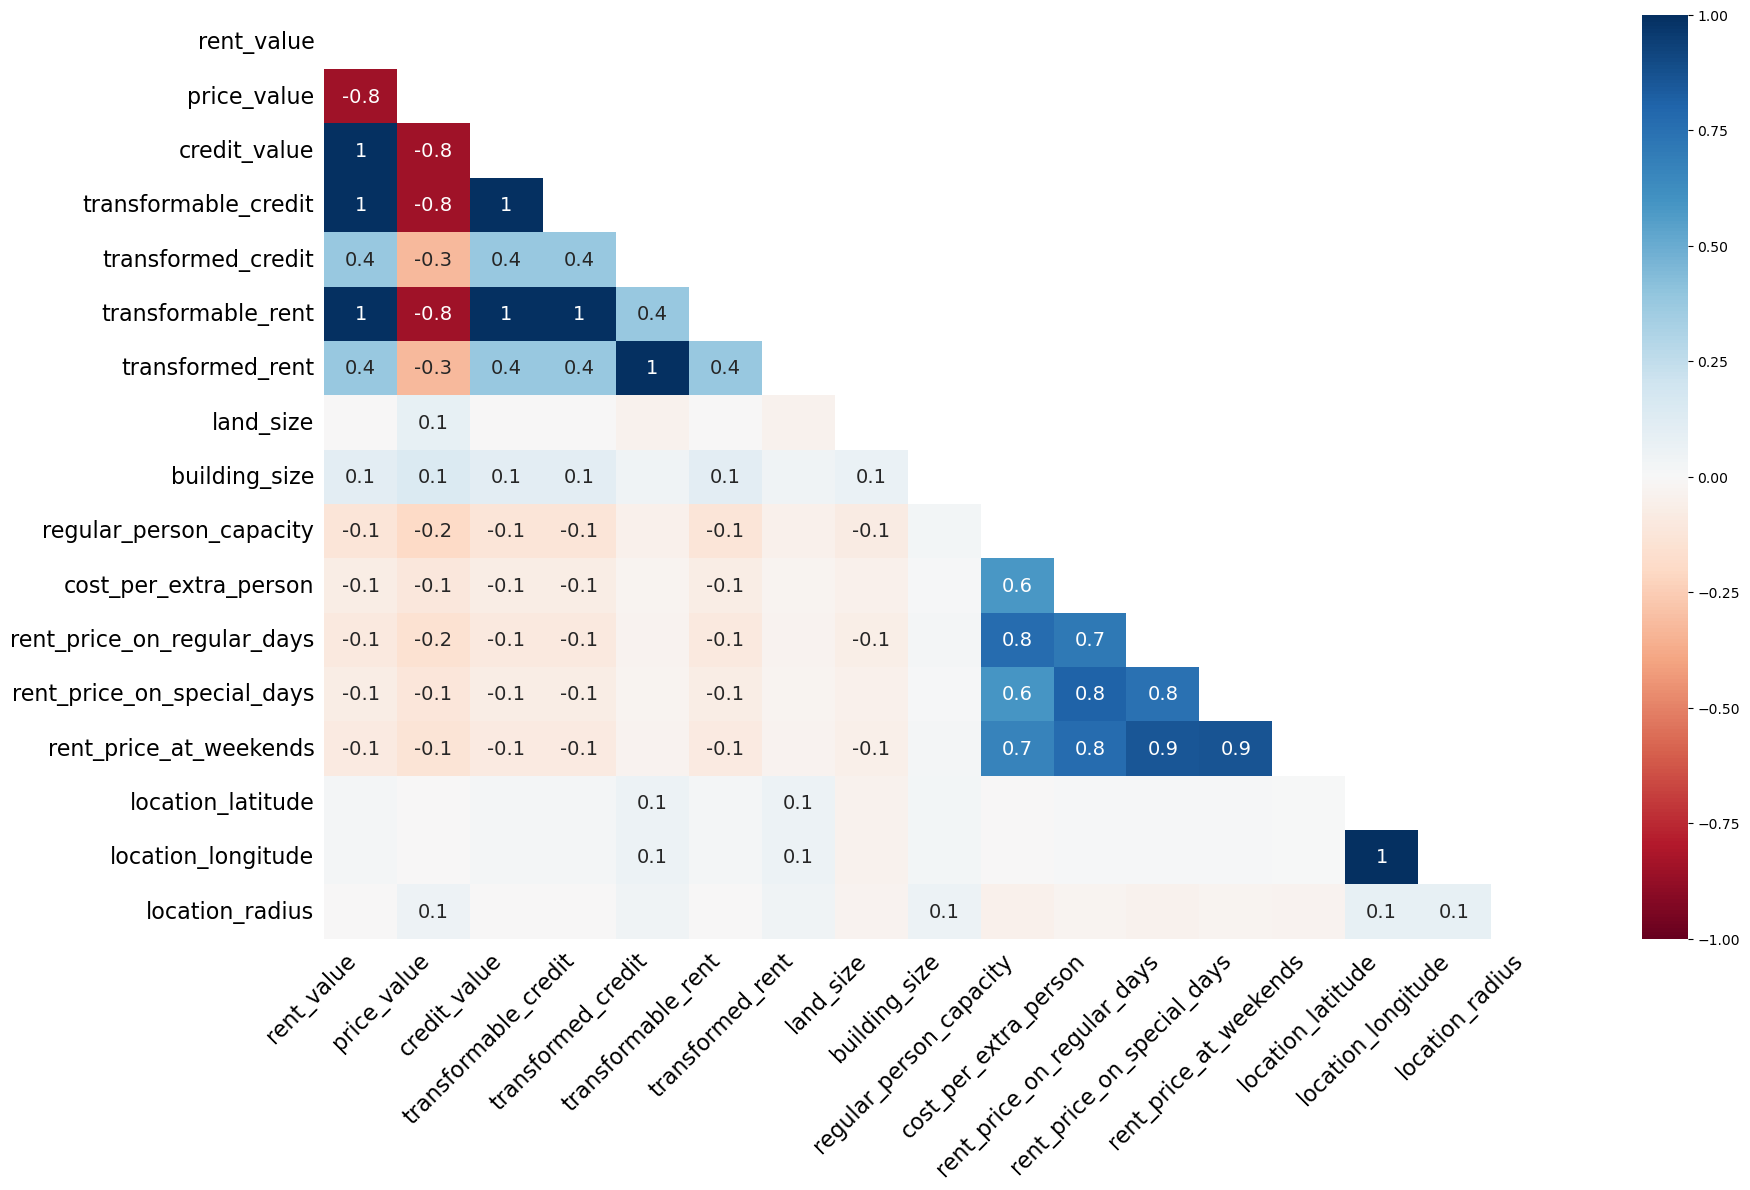

In [7]:


#msno.bar(df)         # bar plot showing % missing per column
msno.bar(df)
plt.show()

#msno.matrix(df)      # matrix view (like the heatmap)
msno.matrix(df)
plt.show()

numeric_cols = df.select_dtypes(include=['int64', 'float64', 'float32', 'Int64', 'int32'])
#msno.heatmap(df)     # correlation of missingness between columns
msno.heatmap(numeric_cols)
plt.show()


## Duplicate
2. آیا ردیف‌های تکراری در داده وجود دارد؟

DataFrame.duplicated(keep = ['first', 'last'])

DataFrame.drop_duplicates(inplace, keep = ['first','last'])

Dataframe.reset_index(inplace, drop)

In [220]:
dup_series = df.duplicated().sum() 
dup_series

np.int64(0)

3.آیا چیزی از جنس تناقض و ناسازگاری مقداری در داده مشاهده می‌کنید؟ به عنوان نمونه به این صورت که در یک سلول مقدار غیرمرتبط و از نظر منطقی نادرست نوشته شده باشد. مثلا در ستونی که قرار است متن بیاید عدد آمده باشد یا در ستونی که قرار است عدد یک یا دو رقمی بیاید، مقدار متفاوتی ثبت شده است.

In [88]:
for col in df.columns:
    # Drop NaN for this column
    col_no_nan = df[col].dropna()
    
    print(f"🔹 {col} — {col_no_nan.nunique()} unique values")
    print(f"🔹 value type : {col_no_nan.map(type).value_counts()}")
    print(f"🔹 number of NAN : {df[col].isna().sum()}")
    print("-" * 80)

🔹 cat2_slug — 6 unique values
🔹 value type : cat2_slug
<class 'str'>    1000000
Name: count, dtype: int64
🔹 number of NAN : 0
--------------------------------------------------------------------------------
🔹 cat3_slug — 16 unique values
🔹 value type : cat3_slug
<class 'str'>    999999
Name: count, dtype: int64
🔹 number of NAN : 1
--------------------------------------------------------------------------------
🔹 city_slug — 421 unique values
🔹 value type : city_slug
<class 'str'>    999998
Name: count, dtype: int64
🔹 number of NAN : 2
--------------------------------------------------------------------------------
🔹 neighborhood_slug — 1188 unique values
🔹 value type : neighborhood_slug
<class 'str'>    437139
Name: count, dtype: int64
🔹 number of NAN : 562861
--------------------------------------------------------------------------------
🔹 created_at_month — 46 unique values
🔹 value type : created_at_month
<class 'str'>    1000000
Name: count, dtype: int64
🔹 number of NAN : 0
-------

In [41]:
#check categorical columns
exclude_cols = ['title', 'description','created_at_month']

for col in df.columns:
    if df[col].dtype == 'object' and col not in exclude_cols:  # categorical column
        print(f"Column: {col}")
        print(f"number of notnull values: {df[col].notna().sum()}")
        print(f"number of NAN values: {df[col].isna().sum()}")
        print(df[col].value_counts(dropna=False))  # include NaN counts
        print("-" * 70)


Column: cat2_slug
number of notnull values: 1000000
number of NAN values: 0
cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64
----------------------------------------------------------------------
Column: cat3_slug
number of notnull values: 999999
number of NAN values: 1
cat3_slug
apartment-sell                        303385
apartment-rent                        211880
plot-old                              133570
house-villa-sell                      121753
house-villa-rent                       64678
shop-rent                              45993
shop-sell                              21855
office-rent                            21418
suite-apartment                        16465
presell                                15781
villa                                  12899
industry-agriculture-business-sell     11851
indust

## inconsistencies </br>
It is seen data inconsistencies in **floor** , **total_floors_count** , **has_balcony** , **extra_person_capacity** columns.</br>
in **floor** there are float and str and negetive number and 30+</br>
in **total_floors_count** there are float and str and **unselect** and 30+ </br>
in **extra_person_capacity** there are float and str and 30+</br>
in **has_balcony** there are 'true', 'false', **'unselect'**, True, False</br>


In [6]:
#first of all,we replace all unselect value in whole data frame with nan(except title and description):
cols_to_clean = df.columns.difference(['title', 'description'])

df[cols_to_clean] = df[cols_to_clean].replace(
    r'(?i)unselect', 
    np.nan, 
    regex=True
)
print(df.has_balcony.unique())

#has_balcony: replace 'true' and 'false' string with boolean True and False respectively:
df['has_balcony'] = (
    df['has_balcony']
    .str.lower()                     # make 'TRUE', 'True', etc. consistent
    .replace({'true': True, 'false': False})
)


bool_cols = [
    'has_gas', 'has_water', 'has_elevator',
    'has_warehouse', 'has_parking', 'is_rebuilt', 
    'has_electricity', 'has_security_guard', 'has_barbecue',
    'has_pool', 'has_jacuzzi', 'has_sauna'
]
for col in bool_cols:
    if col not in df.columns:
        print(f"Skipping missing column: {col}")
        continue

    # map known patterns → boolean
    df[col] = df[col].map(
        {
            'True': True, 'False': False,
            '1': True, '0': False,
            1: True, 0: False,
            True: True, False: False
        }
    )

    # convert to boolean dtype
    df[col] = df[col].astype('boolean')

    print(f"Column cleaned: {col}")


[nan 'true' 'false' True False]
Column cleaned: has_gas
Column cleaned: has_water
Column cleaned: has_elevator
Column cleaned: has_warehouse
Column cleaned: has_parking
Column cleaned: is_rebuilt
Column cleaned: has_electricity
Column cleaned: has_security_guard
Column cleaned: has_barbecue
Column cleaned: has_pool
Column cleaned: has_jacuzzi
Column cleaned: has_sauna


In [7]:
# floor
df.loc[df['floor'] == '30+', 'floor'] = 31
df['floor'] = pd.to_numeric(df['floor'], errors='coerce').astype('Int64')

# total_floors_count
df.loc[df['total_floors_count'] == '30+', 'total_floors_count'] = 31
df['total_floors_count'] = pd.to_numeric(df['total_floors_count'], errors='coerce').astype('Int64')

# rooms_count
mapping = {
    'یک': 1,
    'دو': 2,
    'سه': 3,
    'چهار': 4,
    'پنج یا بیشتر': 5,
    'بدون اتاق': 0,
    np.nan: np.nan  # keep NaN as NaN
}
df['rooms_count'] = df['rooms_count'].map(mapping)
df['rooms_count'] = pd.to_numeric(df['rooms_count'], errors='coerce').astype('Int64')

#unit_per_floor
df['unit_per_floor'] = df['unit_per_floor'].replace('more_than_8', 9)# Replace 'more_than_8' with 9
df['unit_per_floor'] = pd.to_numeric(df['unit_per_floor'], errors='coerce')# Convert the rest of the column to numeric (strings → numbers)

# Construction year
def persian_to_english(s):
    if pd.isna(s):
        return s
    persian_digits = '۰۱۲۳۴۵۶۷۸۹'
    english_digits = '0123456789'
    trans_table = str.maketrans(persian_digits, english_digits)
    return str(s).translate(trans_table)

df.loc[df['construction_year'] == 'قبل از ۱۳۷۰', 'construction_year'] = '۱۳۷۰'
df['construction_year'] = df['construction_year'].apply(persian_to_english)
df['construction_year'] = pd.to_numeric(df['construction_year'], errors='coerce').astype('Int64')

#extra_person_capacity
df.loc[df['extra_person_capacity'] == '30+', 'extra_person_capacity'] = 30
df['extra_person_capacity'] = pd.to_numeric(df['extra_person_capacity'], errors='coerce').astype('Int64')

In [21]:
print(f"floor values:{df.floor.value_counts(dropna=False)}")
print("-" * 80)
print(f"total_floors_count values:{df.total_floors_count.value_counts(dropna=False)}")
print("-" * 80)
print(f"has_balcony values:{df.has_balcony.value_counts(dropna=False)}")
print("-" * 80)
print(f"extra_person_capacity values:{df.extra_person_capacity.value_counts(dropna=False)}")
print(f"construction_year values:{df.construction_year.value_counts(dropna=False)}")
print(f"rooms_count values:{df.rooms_count.value_counts(dropna=False)}")
print(f"unit_per_floor values:{df.unit_per_floor.value_counts(dropna=False)}")

floor values:floor
<NA>    458252
2       128518
1       119565
3       109324
4        71927
5        37604
0        35855
6        13784
7         5713
-1        4464
8         3298
10        2302
9         2193
11        1474
12        1232
13         834
14         783
31         675
15         450
16         313
17         269
20         214
18         189
19         153
21         115
25         102
22          87
23          76
30          62
24          61
27          35
28          32
26          25
29          20
Name: count, dtype: Int64
--------------------------------------------------------------------------------
total_floors_count values:total_floors_count
<NA>    695773
4        89581
5        79951
3        52795
6        28893
2        22747
7         8276
8         4588
14        3048
10        2917
9         2005
12        1783
11        1401
13        1066
15         993
16         715
20         621
18         455
25         432
21         323
19         311
17  

## check outliers

In [10]:
# سال ساخت
invalid_years = df[(df['construction_year'] < 1370) | (df['construction_year'] > 1403)]
if len(invalid_years) > 0:
    print("construction_year:")
    print(invalid_years[['construction_year']])
    print()
# قیمت منفی
invalid_price = df[df['price_value'] < 0]
if len(invalid_price) > 0:
    print("price_value (negative):")
    print(invalid_price[['price_value']])
    print()
invalid_price = df[df['credit_value'] < 0]
if len(invalid_price) > 0:
    print("credit_value (negative):")
    print(invalid_price[['credit_value']])
    print()
invalid_price = df[df['rent_value'] < 0]
if len(invalid_price) > 0:
    print("rent_value (negative):")
    print(invalid_price[['rent_value']])
    print()
invalid_price = df[df['transformed_credit'] < 0]
if len(invalid_price) > 0:
    print("transformed_credit (negative):")
    print(invalid_price[['transformed_credit']])
    print()
invalid_price = df[df['transformed_rent'] < 0]
if len(invalid_price) > 0:
    print("transformed_rent (negative):")
    print(invalid_price[['transformed_rent']])
    print()



In [118]:
df.columns

Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_value', 'rent_to_single', 'rent_type', 'price_mode',
       'price_value', 'credit_mode', 'credit_value', 'rent_credit_transform',
       'transformable_price', 'transformable_credit', 'transformed_credit',
       'transformable_rent', 'transformed_rent', 'land_size', 'building_size',
       'deed_type', 'has_business_deed', 'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',
       'regular_person_capacity', 'extra_person

In [8]:

# remove from data 1111111..., 22222222...., 333333333... ,4444...,5555..,6666...,777777...,8888...,999999999... patterns thar are fake numbers
cols = ['rent_value', 'price_value', 'credit_value', 'transformable_credit','transformed_credit','transformable_rent', 'transformed_rent',
       'rent_price_on_regular_days','rent_price_on_special_days','rent_price_at_weekends','cost_per_extra_person']

pattern_anywhere = r'(1{5,}|2{5,}|3{5,}|4{5,}|5{5,}|6{5,}|7{5,}|8{5,}|9{5,})'

for col in cols:
    df[col + '_str'] = df[col].astype('Int64').astype(str)
    df[col + '_str'] = df[col + '_str'].str.replace(r'\.0$', '', regex=True)
    mask = df[col + '_str'].str.contains(pattern_anywhere, na=False)
    df.loc[mask, col] = np.nan
    

df.drop(columns=[c + '_str' for c in cols if (c + '_str') in df.columns],
        inplace=True)

    
df[[
    'rent_value',
    'credit_value',
    'price_value',
    'transformed_credit',
    'transformable_credit',
    'transformed_rent',
    'transformable_rent','rent_price_on_regular_days','rent_price_on_special_days','rent_price_at_weekends','cost_per_extra_person'
]].describe()

,rent_value,credit_value,price_value,transformed_credit,transformable_credit,transformed_rent,transformable_rent,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,cost_per_extra_person
count,"341,873","345,134","554,529","72,379","345,124","72,279","341,799","17,743","10,207","13,273","10,048"
mean,"1,081,044,270","9,116,643,639","14,047,848,073","884,786,975","9,116,898,745","16,223,315","1,081,277,589","103,104,925,625","1,160,582,662","15,277,319,944","40,151,583"
std,"318,830,991,707","1,503,133,773,837","450,794,911,398","2,666,853,737","1,503,155,549,713","52,221,980","318,865,503,241","6,806,600,038,238","81,303,572,345","1,738,176,619,818","2,825,759,882"
min,0,0,0,0,0,0,0,0,0,0,0
25%,"400,000","100,000,000","1,500,000,000","200,000,000","100,000,000","1,000,000","400,000","400,000","600,000","580,000","50,000"
50%,"5,000,000","250,000,000","2,900,000,000","400,000,000","250,000,000","6,000,000","5,000,000","800,000","1,200,000","1,100,000","100,000"
75%,"12,000,000","500,000,000","5,950,000,000","850,000,000","500,000,000","15,000,000","12,000,000","1,600,000","2,500,000","2,500,000","200,000"
max,"120,000,000,050,040","500,000,000,000,000","90,000,000,000,000","350,000,000,000","500,000,000,000,000","3,000,000,000","120,000,000,050,040","500,600,700,800,900","5,806,807,801,150","200,250,300,400,450","200,300,400,500"


In [50]:
# we need only upper bound because lower bound must be 0
def cap_values(df, column):
    """
    Caps a numeric column:
        lower bound = 0
        upper bound = 99th percentile
    Replaces values below / above bounds with the bounds.
    """
    upper = df[column].quantile(0.99)
    
    df[column] = df[column].clip(lower=0, upper=upper)
    return df

columns_to_cap = [
    'rent_value', 'credit_value', 'price_value',
    'transformed_credit', 'transformed_rent','rent_price_on_regular_days','rent_price_on_special_days','rent_price_at_weekends','cost_per_extra_person'
]

for col in columns_to_cap:
    if col in df.columns:
        df = cap_values(df, col)

df[columns_to_cap].describe()

,rent_value,credit_value,price_value,transformed_credit,transformed_rent,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,cost_per_extra_person
count,"341,872","345,133","554,528","72,379","72,279","17,743","10,207","13,273","10,048"
mean,"13,195,620","472,352,595","5,860,755,356","798,519,964","14,143,513","1,261,229","1,894,071","1,735,702","163,279"
std,"27,795,582","718,446,141","9,825,396,635","1,178,567,019","27,068,803","1,541,603","2,107,179","1,771,511","207,748"
min,0,0,0,0,0,0,0,0,0
25%,"400,000","100,000,000","1,500,000,000","200,000,000","1,000,000","400,000","600,000","580,000","50,000"
50%,"5,000,000","250,000,000","2,900,000,000","400,000,000","6,000,000","800,000","1,200,000","1,100,000","100,000"
75%,"12,000,000","500,000,000","5,950,000,000","850,000,000","15,000,000","1,600,000","2,500,000","2,500,000","200,000"
max,"200,000,000","5,000,000,000","70,000,000,000","8,000,000,000","185,000,000","11,000,000","12,305,441","10,000,000","1,500,000"


In [12]:
df[['building_size', 'land_size']].describe()

,building_size,land_size
count,"980,394","186,396"
mean,"4,441","4,165"
std,"136,712","121,893"
min,1,1
25%,75,110
50%,103,195
75%,165,280
max,"10,000,000","10,000,000"


In [52]:
# detect outliers for land_size and building_size
def cap_size_outliers(df, column):
    """
    For building_size and land_size:
        lower = 5th percentile
        upper = 98th percentile
    """
    lower = df[column].quantile(0.02)
    upper = df[column].quantile(0.99)

    df[column] = df[column].clip(lower=lower, upper=upper)
    return df

#dff=df.copy()
size_columns = ['building_size', 'land_size']
for col in size_columns:
    if col in df.columns:
        df = cap_size_outliers(df, col)
df[size_columns].describe()


,building_size,land_size
count,"980,392","186,395"
mean,323,308
std,"1,155",520
min,18,50
25%,75,110
50%,103,195
75%,165,280
max,"10,000","4,320"


In [26]:
# this is need for text proccessing
mask_title_len1 = df['title'].astype(str).str.len() == 1
mask_desc_len1  = df['description'].astype(str).str.len() == 1

# Rows where both title and description have length 1
mask_both_len1 = mask_title_len1 & mask_desc_len1

# View the problematic rows
df[mask_both_len1]


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_to_single,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
52251,residential-sell,apartment-sell,tehran,east-tehranpars,2024-08-01 00:00:00,NaN,پ,پ,NaN,NaN,NaN,NaN,مقطوع,"1,616",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,300,NaN,NaN,1,3,<NA>,NaN,NaN,True,False,True,1403,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stone,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,36,52,NaN
393040,residential-rent,house-villa-rent,pool,NaN,2024-06-01 00:00:00,NaN,پ,پ,مقطوع,"1,500,000",NaN,NaN,NaN,NaN,مقطوع,"10,000,000",False,False,"10,000,000",NaN,"1,500,000",NaN,161,161,NaN,NaN,<NA>,1,<NA>,NaN,True,NaN,True,False,1387,False,True,NaN,True,True,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,36,51,NaN


In [27]:
#check inconsistency in title and description:
cols = ['title', 'description']
valid_type = str
for col in cols:
    mask_non_text = ~df[col].map(lambda x: isinstance(x, valid_type))
    df_non_text = df[mask_non_text]
    
    print(f"Column: {col}")
    print(f"Number of non-text rows: {mask_non_text.sum()}")
    print(df_non_text[[col]])   # show only the problematic column
    print("-" * 40)

Column: title
Number of non-text rows: 54
       title
17143    NaN
30413    NaN
39234    NaN
87504    NaN
157839   NaN
206776   NaN
219672   NaN
236728   NaN
259087   NaN
263994   NaN
286743   NaN
330846   NaN
334115   NaN
335588   NaN
339491   NaN
342163   NaN
343544   NaN
352431   NaN
357159   NaN
362220   NaN
402881   NaN
406756   NaN
409420   NaN
409965   NaN
415677   NaN
425524   NaN
431761   NaN
458918   NaN
477642   NaN
512227   NaN
515701   NaN
528985   NaN
546641   NaN
560194   NaN
597568   NaN
616023   NaN
644350   NaN
733614   NaN
738014   NaN
739462   NaN
746268   NaN
749993   NaN
774656   NaN
776524   NaN
784377   NaN
813549   NaN
827380   NaN
827493   NaN
851250   NaN
862929   NaN
935940   NaN
936938   NaN
962391   NaN
985391   NaN
----------------------------------------
Column: description
Number of non-text rows: 0
Empty DataFrame
Columns: [description]
Index: []
----------------------------------------


In [9]:
df.loc[338801, 'cat3_slug'] = 'office_rent'
print(df.loc[338801, df.columns[1]])

office_rent


In [54]:
valid_types = (str)   # expected type
col = "city_slug"

# mask for rows that are NOT valid
mask_unusual = ~df[col].map(lambda x: isinstance(x, valid_types))

# view unusual rows
df_unusual = df[mask_unusual]
print(df_unusual[[col]])

# drop the unusual rows from the original DataFrame
df = df[~mask_unusual]

# check
print(df[col].dtype)
print(df.shape)


Empty DataFrame
Columns: [city_slug]
Index: []
object
(999998, 60)


In [33]:
#check inconsistency in neighborhood_slug
valid_types = (str)   # you can change this
col = "neighborhood_slug"
mask_unusual = ~df[col].map(lambda x: isinstance(x, valid_types))
df_unusual = df[mask_unusual].dropna()
print(df_unusual[[col]])     # only the problematic column
#print(df_unusual)            # full rows

Empty DataFrame
Columns: [neighborhood_slug]
Index: []


In [10]:
df2 = df[df['cat2_slug'] != 'real-estate-services']


In [70]:
df[df['cat2_slug'] == 'real-estate-services'].shape

(19403, 60)

In [56]:
# Rent categories
rent_categories = [ 'residential-rent', 'commercial-rent']
rent_cols = [
    'cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_value', 'rent_to_single', 'rent_type',  'credit_mode', 'credit_value', 
       'land_size', 'building_size',
       'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'location_latitude', 'location_longitude'
]

df_rent = df2[df2['cat2_slug'].isin(rent_categories)][rent_cols]



In [59]:
sell_cols = [
   'cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title',
       'price_mode',
       'price_value',
       'land_size', 'building_size',
       'deed_type', 'has_business_deed', 'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',       
       'location_latitude', 'location_longitude'
]

# Sell categories
sell_categories = [ 'residential-sell', 'commercial-sell']

df_sell = df2[df2['cat2_slug'].isin(sell_categories)][sell_cols]

In [58]:
# Rent categories
temp_rent_categories = ['temporary-rent']
temp_rent_cols = [
    'cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 
       'land_size', 'building_size',
       'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',
       'regular_person_capacity', 'extra_person_capacity',
       'cost_per_extra_person', 'rent_price_on_regular_days',
       'rent_price_on_special_days', 'rent_price_at_weekends',
       'location_latitude', 'location_longitude'
]

df_temp_rent = df2[df2['cat2_slug'].isin(temp_rent_categories)][temp_rent_cols]



In [29]:
print("Rent ads:", df_rent.shape)
print("Sell ads:", df_sell.shape)
print("temporary rent ads:", df_temp_rent.shape)

Rent ads: (353124, 42)
Sell ads: (597568, 41)
temporary rent ads: (29903, 43)


In [266]:
# info about rent dataset
df_rent.info()
df_rent.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 353124 entries, 2 to 999999
Data columns (total 43 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat2_slug                353124 non-null  object 
 1   cat3_slug                353124 non-null  object 
 2   city_slug                353124 non-null  object 
 3   neighborhood_slug        178462 non-null  object 
 4   created_at_month         353124 non-null  object 
 5   user_type                104482 non-null  object 
 6   description              353124 non-null  object 
 7   title                    353093 non-null  object 
 8   rent_mode                352981 non-null  object 
 9   rent_value               343609 non-null  float64
 10  rent_to_single           19 non-null      object 
 11  rent_type                103952 non-null  object 
 12  credit_mode              352981 non-null  object 
 13  credit_value             346119 non-null  float64
 14  land_size

,rent_value,credit_value,land_size,building_size,floor,rooms_count,total_floors_count,unit_per_floor,construction_year,location_latitude,location_longitude,location_radius
count,"343,609","346,119","64,660","352,985","233,214",0,"117,210","117,252","352,521","235,090","235,090","118,324"
mean,"8,573,945","367,963,054",176,107,3,<NA>,5,2,"1,393",35,52,477
std,"9,613,647","336,114,362",121,64,2,<NA>,3,1,8,2,3,103
min,0,0,1,1,-1,<NA>,2,1,"1,370",24,43,0
25%,"500,000","100,000,000",94,68,1,<NA>,3,1,"1,389",34,51,500
50%,"5,000,000","250,000,000",140,92,2,<NA>,4,2,"1,395",36,51,500
75%,"12,000,000","500,000,000",210,130,3,<NA>,5,2,"1,400",36,52,500
max,"29,250,000","1,100,000,000",535,300,31,<NA>,31,9,"1,403",40,75,500


In [135]:
nan_cols = (df_rent.isna().mean() * 100).sort_values(ascending=False)

nan_rows = (df_rent.isna().mean(axis=1) * 100).sort_values(ascending=False)

print(nan_cols.head(30))
print(nan_rows.head(30))

rent_to_single            100
has_sauna                  99
has_jacuzzi                99
has_pool                   99
has_security_guard         99
has_barbecue               99
has_gas                    98
has_electricity            98
has_water                  98
land_size                  82
rent_type                  70
user_type                  70
total_floors_count         66
unit_per_floor             66
building_direction         66
has_cooling_system         61
has_heating_system         58
has_warm_water_provider    57
floor_material             54
has_restroom               54
neighborhood_slug          49
has_balcony                48
is_rebuilt                 39
floor                      33
has_elevator               33
location_latitude          33
location_longitude         33
has_parking                15
has_warehouse              15
rent_value                  1
dtype: float64
78629    74
946827   71
338062   71
930879   71
374174   71
205731   71
769786   71
5

In [60]:
df_rent = df_rent[df_rent['rent_value'].notna() | df_rent['credit_value'].notna()]# remove rows that has not price
df_temp_rent = df_temp_rent[df_temp_rent['rent_price_on_regular_days'].notna() | df_temp_rent['rent_price_on_special_days'].notna() | df_temp_rent['rent_price_at_weekends'].notna()]
df_sell = df_sell[df_sell['price_value'].notna() ]
df_sell= df_sell[df_sell['price_mode'].ne('مجانی')]


In [66]:
df_rent = df_rent[df_rent['rent_value'].notna() | df_rent['credit_value'].notna()]# remove rows that has not price

#Drop columns with >70% NaN and Drop rows with >88% NaN
nan_percent_row = df_rent.isna().mean(axis=1) * 100# Calculate NaN percentage per row
df_rent=df_rent[(nan_percent_row <= 90) ]# Keep rows with <= 95% NaN

nan_percent_col = df_rent.isna().mean() * 100 # Calculate NaN percentage per column
df_rent = df_rent.loc[:, nan_percent_col <= 90] # Keep columns with <= 70% NaN
df_rent.shape

(346197, 33)

#  تحلیل اکتشافی داده EDA

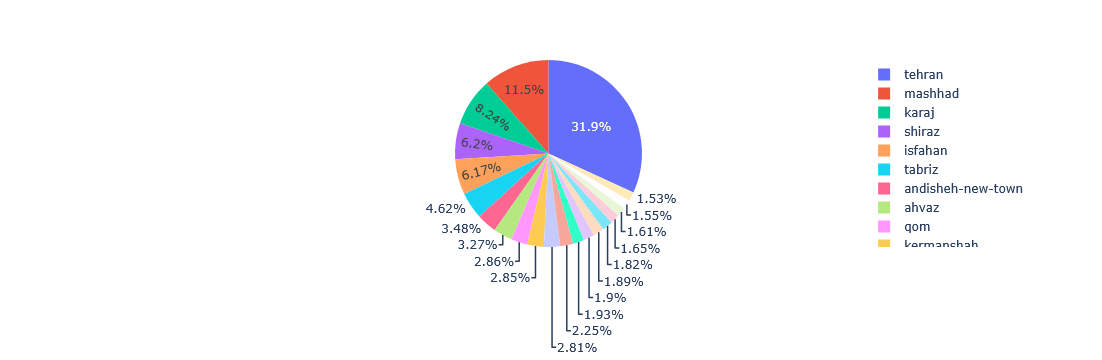

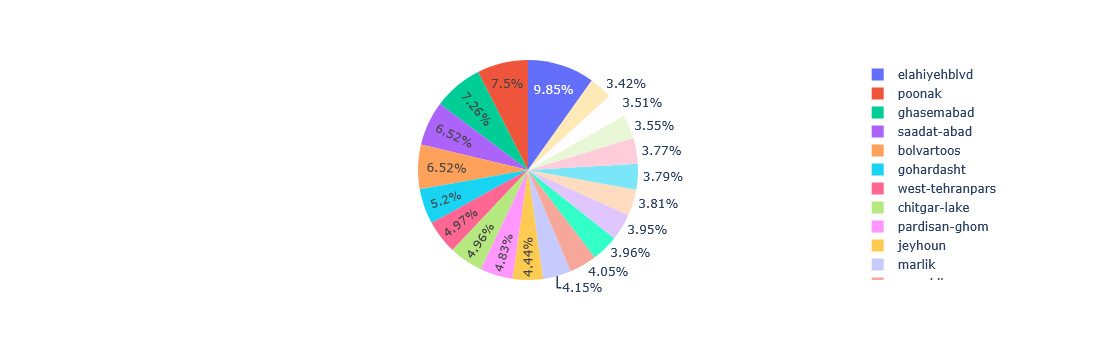

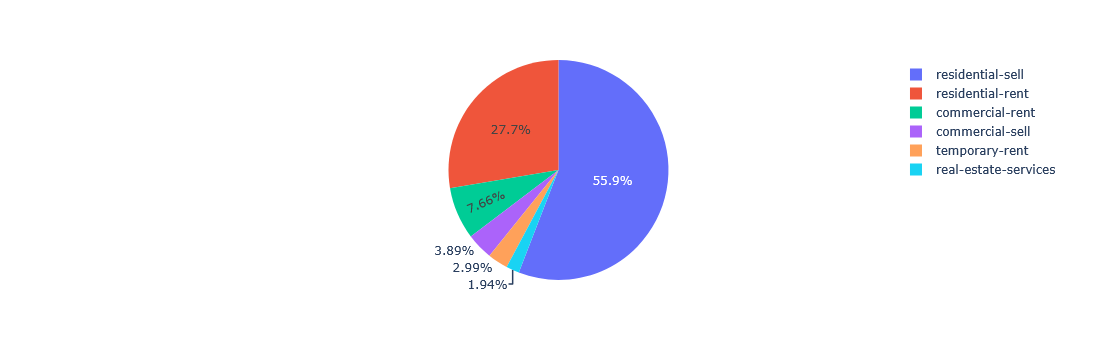

In [14]:
def plot_line_chart(df,column,line=""):
    if line =="":
        line = df[column].value_counts().keys()[0:20]
    data=df[column].value_counts()[0:20]
    fig=px.line(x=line,y=data)
    fig.show()

def plot_bar_chart(df,column,line=""):
    if line =="":
        line = df[column].value_counts().keys()[0:20]
    data=df[column].value_counts()[0:20]
    fig=px.bar(x=line,y=data)
    fig.show()
    
def plot_pie_chart(df,column,line=""):
    if line =="":
        line = df[column].value_counts().keys()[0:20]
    data=df[column].value_counts()[0:20]
    fig=px.pie(names=line,values=data)
    fig.show()
#df["neighborhood_slug"].value_counts().keys()[0:10]
plot_pie_chart(df,"city_slug")
plot_pie_chart(df,"neighborhood_slug")
plot_pie_chart(df,"cat2_slug")

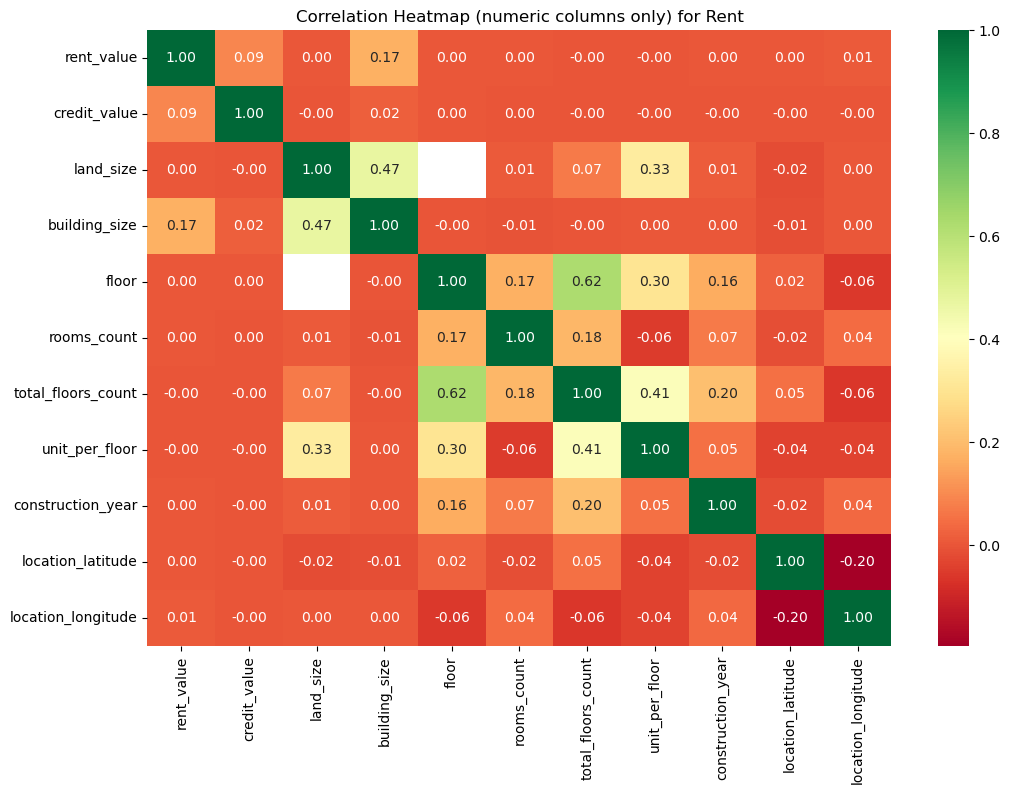

In [31]:
numeric_df = df_rent.select_dtypes(include=['int64', 'float64', 'float32', 'Int64', 'int32'])

corr_matrix = numeric_df.corr()


plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Correlation Heatmap (numeric columns only) for Rent" )
plt.show()


In [129]:
#info about temporary rent dataset
df_temp_rent.info()
df_temp_rent.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 17972 entries, 0 to 999998
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cat2_slug                   17972 non-null  object 
 1   cat3_slug                   17972 non-null  object 
 2   city_slug                   17972 non-null  object 
 3   neighborhood_slug           6187 non-null   object 
 4   created_at_month            17972 non-null  object 
 5   user_type                   1650 non-null   object 
 6   description                 17972 non-null  object 
 7   title                       17970 non-null  object 
 8   land_size                   0 non-null      float64
 9   building_size               17972 non-null  float64
 10  floor                       0 non-null      Int64  
 11  rooms_count                 17972 non-null  Int64  
 12  total_floors_count          0 non-null      Int64  
 13  unit_per_floor              0 non-n

,land_size,building_size,floor,rooms_count,total_floors_count,unit_per_floor,construction_year,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude
count,0,"17,972",0,"17,972",0,0,0,"17,972","14,962","9,591","17,743","10,207","13,273","12,370","12,370"
mean,NaN,"10,432",<NA>,2,<NA>,NaN,<NA>,6,5,"160,934","1,261,229","1,894,268","1,735,702",35,52
std,NaN,"172,430",<NA>,1,<NA>,NaN,<NA>,7,6,"201,561","1,541,603","2,108,152","1,771,511",3,3
min,NaN,1,<NA>,0,<NA>,NaN,<NA>,1,0,0,0,0,0,24,44
25%,NaN,70,<NA>,1,<NA>,NaN,<NA>,3,2,"50,000","400,000","600,000","580,000",34,50
50%,NaN,100,<NA>,2,<NA>,NaN,<NA>,4,3,"100,000","800,000","1,200,000","1,100,000",36,51
75%,NaN,460,<NA>,2,<NA>,NaN,<NA>,6,5,"200,000","1,600,000","2,500,000","2,500,000",37,53
max,NaN,"10,000,000",<NA>,5,<NA>,NaN,<NA>,50,30,"1,500,000","11,000,000","12,324,937","10,000,000",40,62


In [20]:


nan_cols = (df_temp_rent.isna().mean() * 100).sort_values(ascending=False)

nan_rows = (df_temp_rent.isna().mean(axis=1) * 100).sort_values(ascending=False)

print(nan_cols.head(30))
print(nan_rows.head(30))

unit_per_floor                100.000000
total_floors_count            100.000000
has_heating_system            100.000000
has_warm_water_provider       100.000000
is_rebuilt                    100.000000
construction_year             100.000000
has_parking                   100.000000
has_warehouse                 100.000000
has_elevator                  100.000000
has_balcony                   100.000000
has_restroom                  100.000000
has_cooling_system            100.000000
floor                         100.000000
building_direction            100.000000
land_size                     100.000000
floor_material                100.000000
user_type                      89.332174
has_sauna                      86.556533
has_jacuzzi                    86.389325
has_security_guard             86.359228
has_pool                       86.074976
has_barbecue                   85.790723
has_gas                        85.543257
has_water                      85.523192
has_electricity 

In [65]:
df_temp_rent = df_temp_rent[df_temp_rent['rent_price_on_regular_days'].notna() | df_temp_rent['rent_price_on_special_days'].notna() | df_temp_rent['rent_price_at_weekends'].notna()]

#Drop columns with >70% NaN and Drop rows with >88% NaN
nan_percent_row = df_temp_rent.isna().mean(axis=1) * 100# Calculate NaN percentage per row
df_temp_rent=df_temp_rent[(nan_percent_row <= 92) ]# Keep rows with <= 95% NaN

nan_percent_col = df_temp_rent.isna().mean() * 100 # Calculate NaN percentage per column
df_temp_rent = df_temp_rent.loc[:, nan_percent_col <= 90] # Keep columns with <= 70% NaN
df_temp_rent.shape

(17972, 26)

In [64]:
numeric_df = df_temp_rent.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_df

['land_size',
 'building_size',
 'floor',
 'rooms_count',
 'total_floors_count',
 'unit_per_floor',
 'construction_year',
 'regular_person_capacity',
 'extra_person_capacity',
 'cost_per_extra_person',
 'rent_price_on_regular_days',
 'rent_price_on_special_days',
 'rent_price_at_weekends',
 'location_latitude',
 'location_longitude']

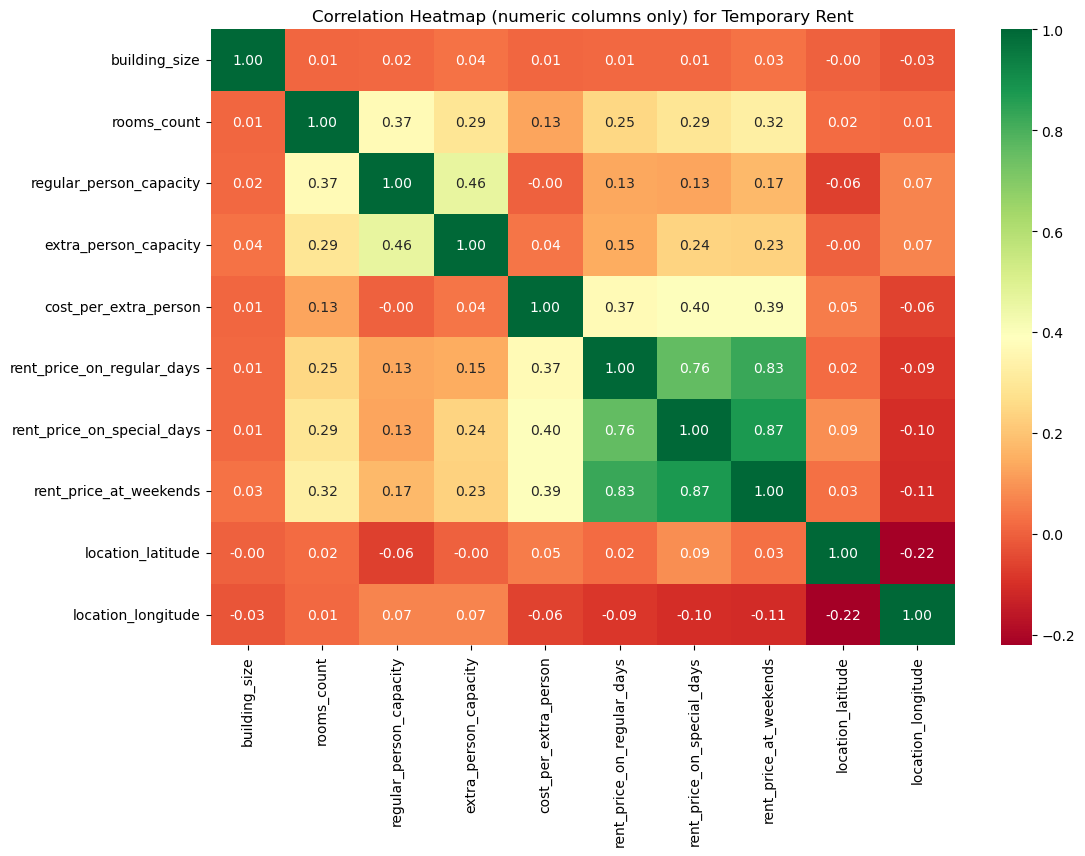

In [134]:
numeric_df = df_temp_rent.select_dtypes(include=['int64', 'float64', 'float32', 'Int64', 'int32'])

corr_matrix = numeric_df.corr()


plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Correlation Heatmap (numeric columns only) for Temporary Rent" )
plt.show()


In [132]:
#info about sell dataset
df_sell.info()
df_sell.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 551415 entries, 1 to 999997
Data columns (total 41 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat2_slug                551415 non-null  object 
 1   cat3_slug                551415 non-null  object 
 2   city_slug                551415 non-null  object 
 3   neighborhood_slug        229554 non-null  object 
 4   created_at_month         551415 non-null  object 
 5   user_type                167184 non-null  object 
 6   description              551415 non-null  object 
 7   title                    551400 non-null  object 
 8   price_mode               551415 non-null  object 
 9   price_value              551415 non-null  float64
 10  land_size                115747 non-null  float64
 11  building_size            551384 non-null  float64
 12  deed_type                247518 non-null  object 
 13  has_business_deed        27077 non-null   object 
 14  floor    

,price_value,land_size,building_size,floor,rooms_count,total_floors_count,unit_per_floor,construction_year,location_latitude,location_longitude
count,"551,415","115,747","551,384","302,935","444,538","184,392","182,197","444,480","361,881","361,881"
mean,"5,881,088,314","3,488","2,165",3,2,5,2,"1,394",35,52
std,"9,840,961,497","113,168","91,104",2,1,3,1,8,2,3
min,1,1,1,-1,0,2,1,"1,370",24,40
25%,"1,500,000,000",130,78,1,2,4,1,"1,390",35,51
50%,"2,900,000,000",200,110,2,2,4,2,"1,396",36,51
75%,"5,980,000,000",300,180,4,2,5,3,"1,402",36,52
max,"70,000,000,000","10,000,000","10,000,000",31,5,31,9,"1,403",40,64


In [138]:
nan_cols = (df_sell.isna().mean() * 100).sort_values(ascending=False)

nan_rows = (df_sell.isna().mean(axis=1) * 100).sort_values(ascending=False)

print(nan_cols.head(30))
print(nan_rows.head(30))

has_sauna                 97
has_jacuzzi               97
has_pool                  96
has_barbecue              96
has_security_guard        96
property_type             96
has_gas                   96
has_electricity           96
has_water                 96
has_business_deed         95
land_size                 79
user_type                 70
unit_per_floor            67
total_floors_count        67
building_direction        64
has_cooling_system        63
has_heating_system        61
has_warm_water_provider   60
neighborhood_slug         58
floor_material            56
has_restroom              56
deed_type                 55
has_balcony               47
floor                     45
has_elevator              45
is_rebuilt                44
location_latitude         34
location_longitude        34
has_warehouse             24
has_parking               24
dtype: float64
508147   80
694192   80
572253   80
38139    80
999473   80
957922   80
681125   80
861493   80
142777   80
693238 

In [64]:
df_sell = df_sell[df_sell['price_value'].notna() ]

#Drop columns with >70% NaN and Drop rows with >88% NaN
nan_percent_row = df_sell.isna().mean(axis=1) * 100# Calculate NaN percentage per row
df_sell=df_sell[(nan_percent_row <= 90) ]# Keep rows with <= 95% NaN

nan_percent_col = df_sell.isna().mean() * 100 # Calculate NaN percentage per column
df_sell = df_sell.loc[:, nan_percent_col <= 90] # Keep columns with <= 70% NaN
df_sell.shape

(551415, 31)

In [271]:
# Get column names of object or category type
cat_columns = df2.select_dtypes(include=['object', 'category']).columns
print(cat_columns)


Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_to_single', 'rent_type', 'price_mode', 'credit_mode',
       'rent_credit_transform', 'transformable_price', 'deed_type',
       'has_business_deed', 'has_balcony', 'has_elevator', 'has_warehouse',
       'has_parking', 'is_rebuilt', 'has_water', 'has_warm_water_provider',
       'has_electricity', 'has_gas', 'has_heating_system',
       'has_cooling_system', 'has_restroom', 'has_security_guard',
       'has_barbecue', 'building_direction', 'has_pool', 'has_jacuzzi',
       'has_sauna', 'floor_material', 'property_type'],
      dtype='object')


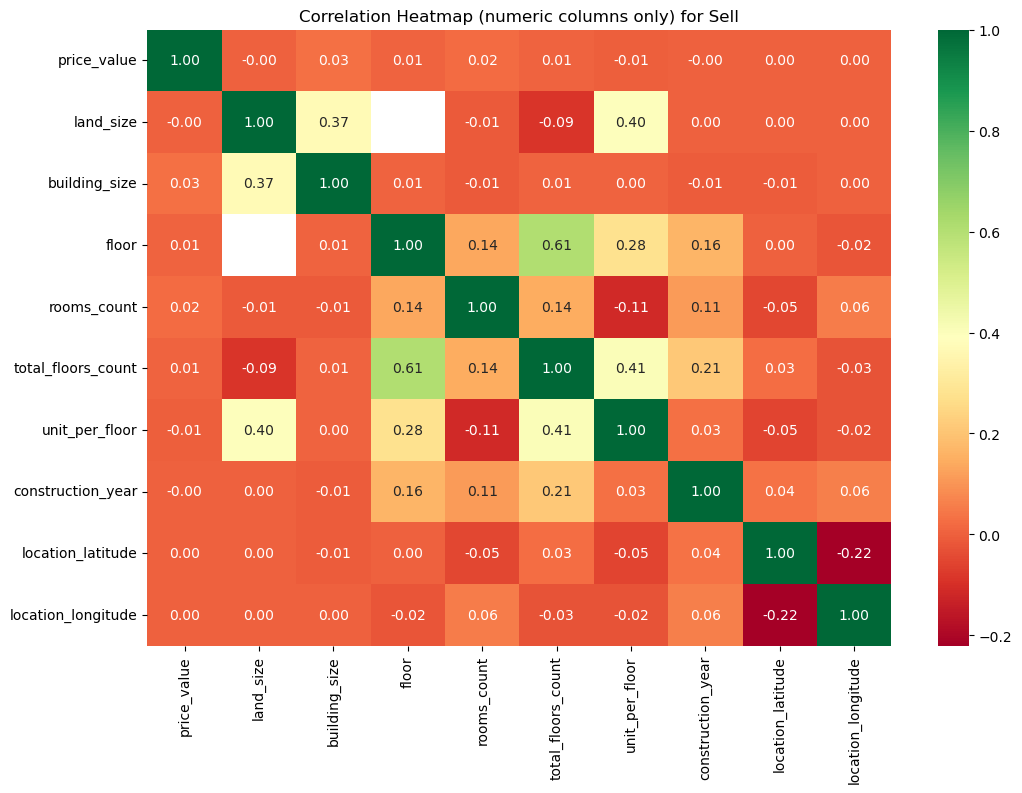

In [37]:
numeric_df = df_sell.select_dtypes(include=['int64', 'float64', 'float32', 'Int64', 'int32'])

corr_matrix = numeric_df.corr()


plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Correlation Heatmap (numeric columns only) for Sell" )
plt.show()


array([[<Axes: title={'center': 'rent_value'}>,
        <Axes: title={'center': 'credit_value'}>,
        <Axes: title={'center': 'land_size'}>],
       [<Axes: title={'center': 'building_size'}>,
        <Axes: title={'center': 'floor'}>,
        <Axes: title={'center': 'rooms_count'}>],
       [<Axes: title={'center': 'total_floors_count'}>,
        <Axes: title={'center': 'unit_per_floor'}>,
        <Axes: title={'center': 'construction_year'}>],
       [<Axes: title={'center': 'location_latitude'}>,
        <Axes: title={'center': 'location_longitude'}>, <Axes: >]],
      dtype=object)

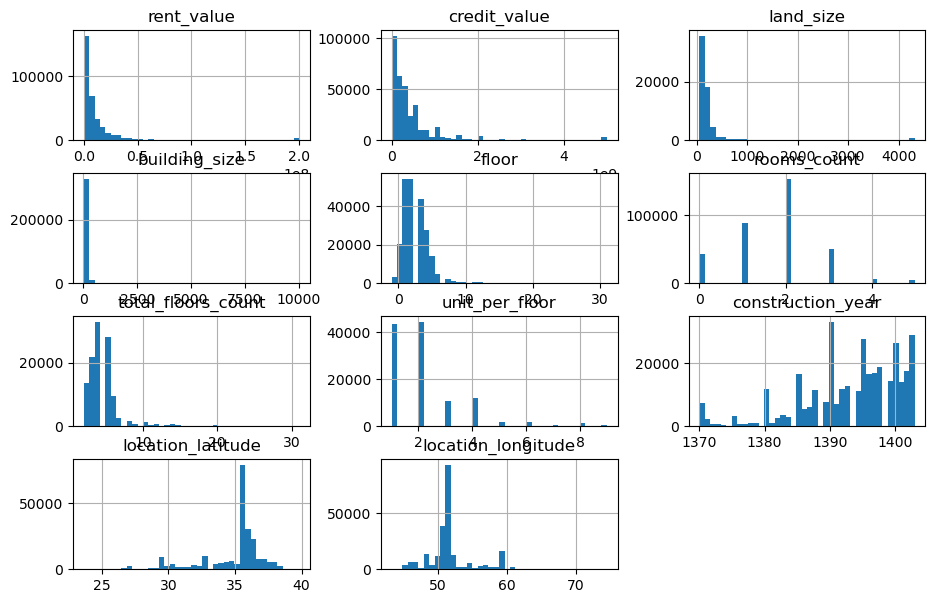

In [67]:
df_rent.hist(bins=40, figsize=(11,7))

array([[<Axes: title={'center': 'price_value'}>,
        <Axes: title={'center': 'land_size'}>,
        <Axes: title={'center': 'building_size'}>],
       [<Axes: title={'center': 'floor'}>,
        <Axes: title={'center': 'rooms_count'}>,
        <Axes: title={'center': 'total_floors_count'}>],
       [<Axes: title={'center': 'unit_per_floor'}>,
        <Axes: title={'center': 'construction_year'}>,
        <Axes: title={'center': 'location_latitude'}>],
       [<Axes: title={'center': 'location_longitude'}>, <Axes: >,
        <Axes: >]], dtype=object)

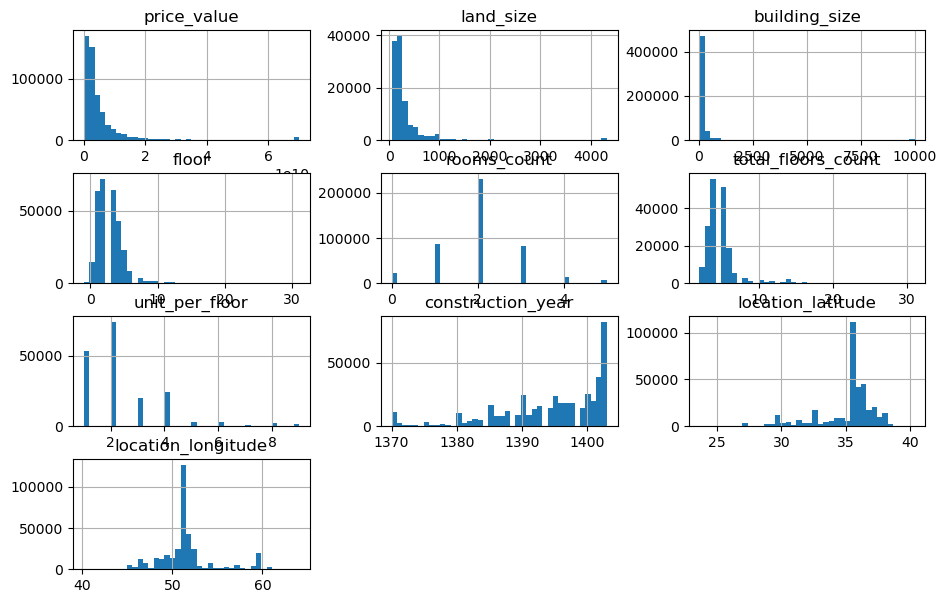

In [68]:
df_sell.hist(bins=40, figsize=(11,7))

array([[<Axes: title={'center': 'building_size'}>,
        <Axes: title={'center': 'rooms_count'}>,
        <Axes: title={'center': 'regular_person_capacity'}>],
       [<Axes: title={'center': 'extra_person_capacity'}>,
        <Axes: title={'center': 'cost_per_extra_person'}>,
        <Axes: title={'center': 'rent_price_on_regular_days'}>],
       [<Axes: title={'center': 'rent_price_on_special_days'}>,
        <Axes: title={'center': 'rent_price_at_weekends'}>,
        <Axes: title={'center': 'location_latitude'}>],
       [<Axes: title={'center': 'location_longitude'}>, <Axes: >,
        <Axes: >]], dtype=object)

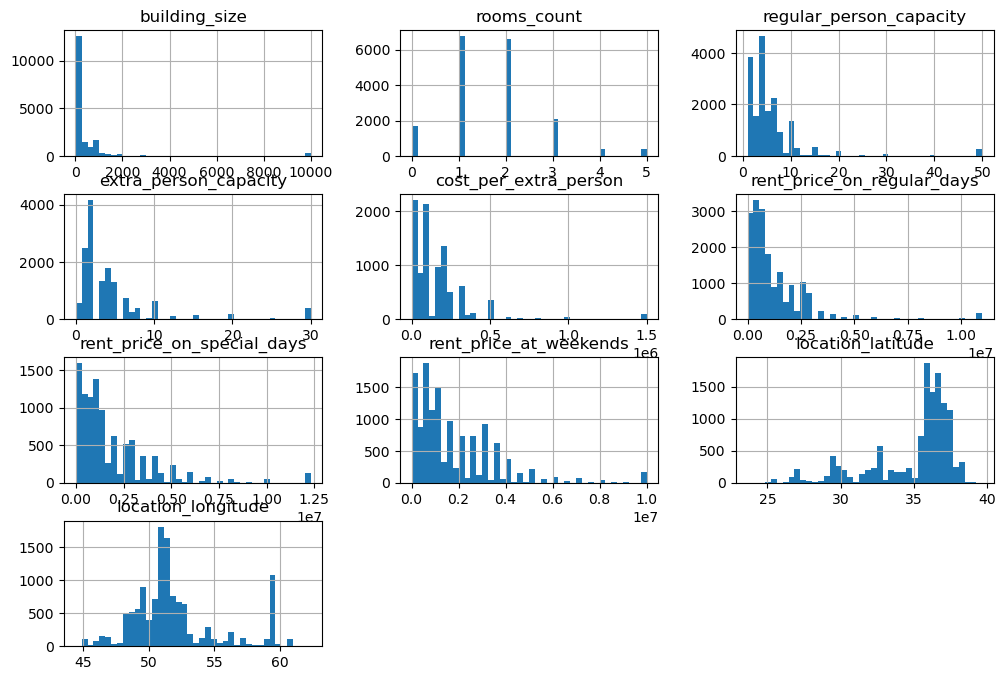

In [69]:
df_temp_rent.hist(bins=40, figsize=(12,8))

Top 15 numeric columns correlated with price_value:
['price_value', 'building_size', 'rooms_count', 'floor', 'total_floors_count', 'unit_per_floor', 'location_latitude', 'land_size', 'construction_year', 'location_longitude']


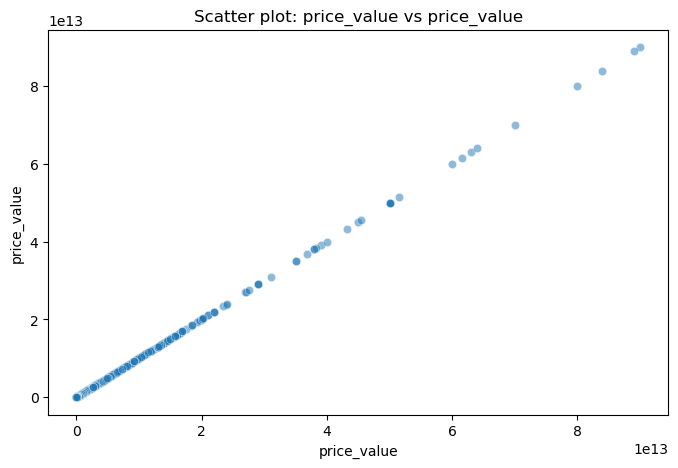

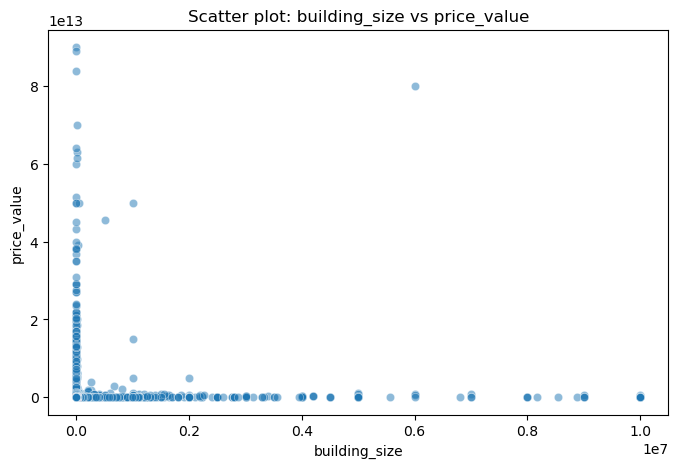

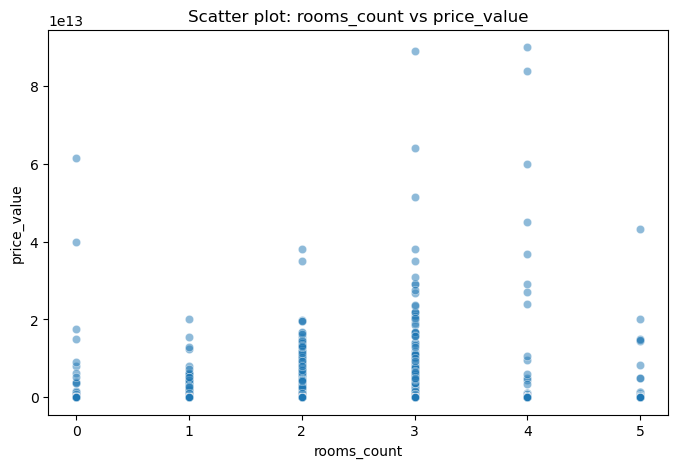

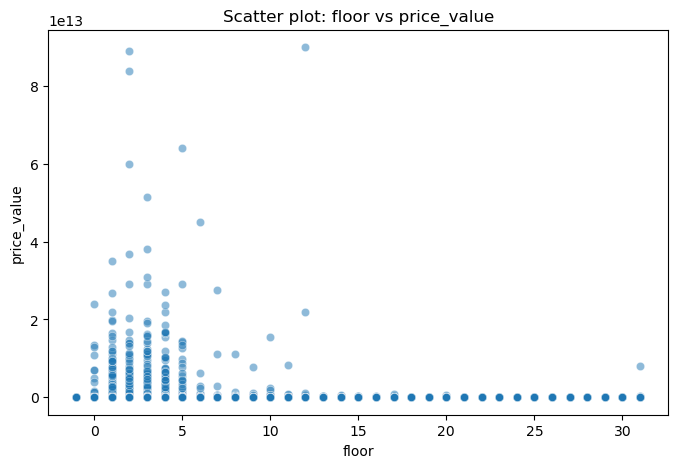

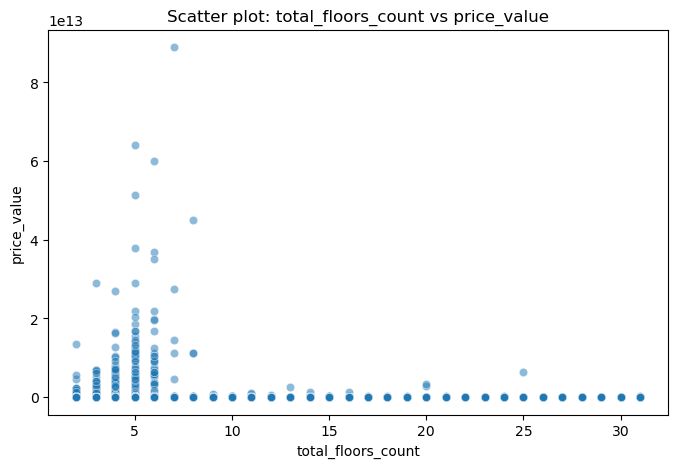

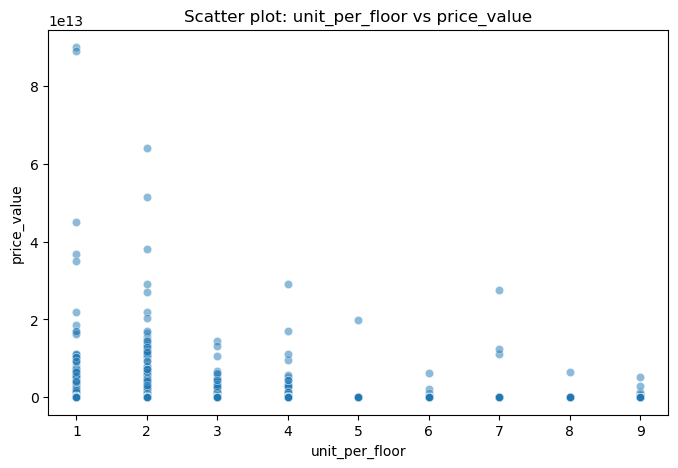

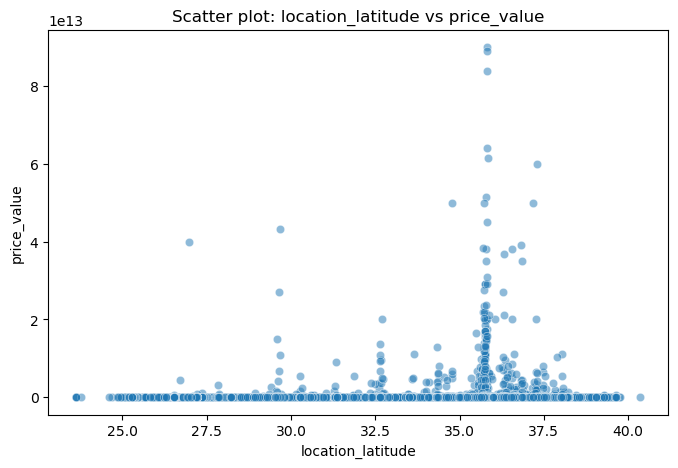

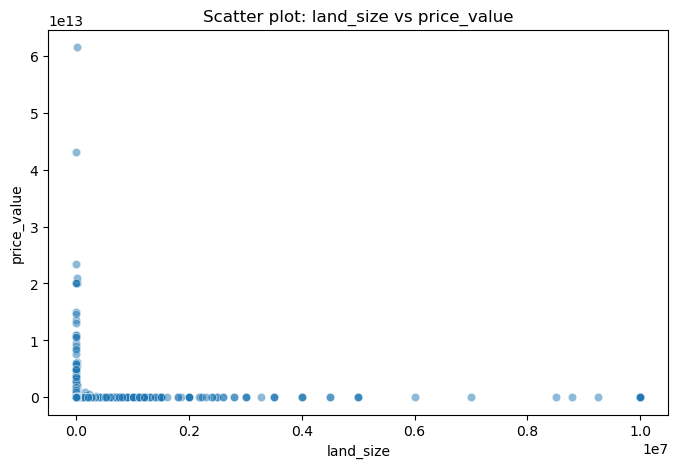

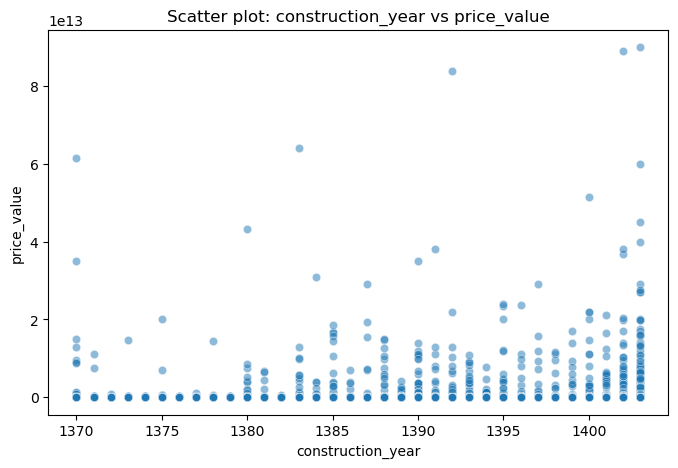

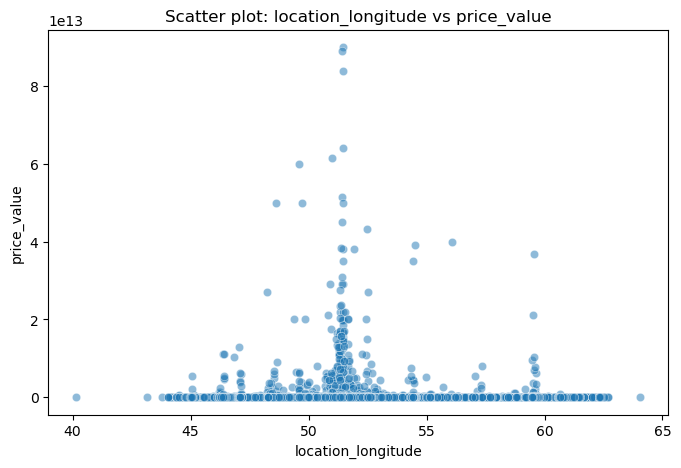

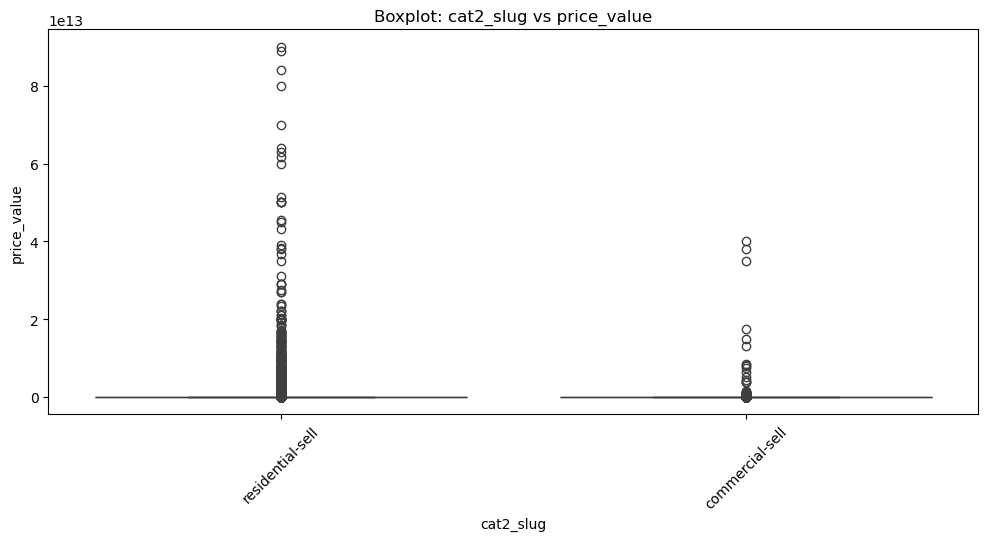

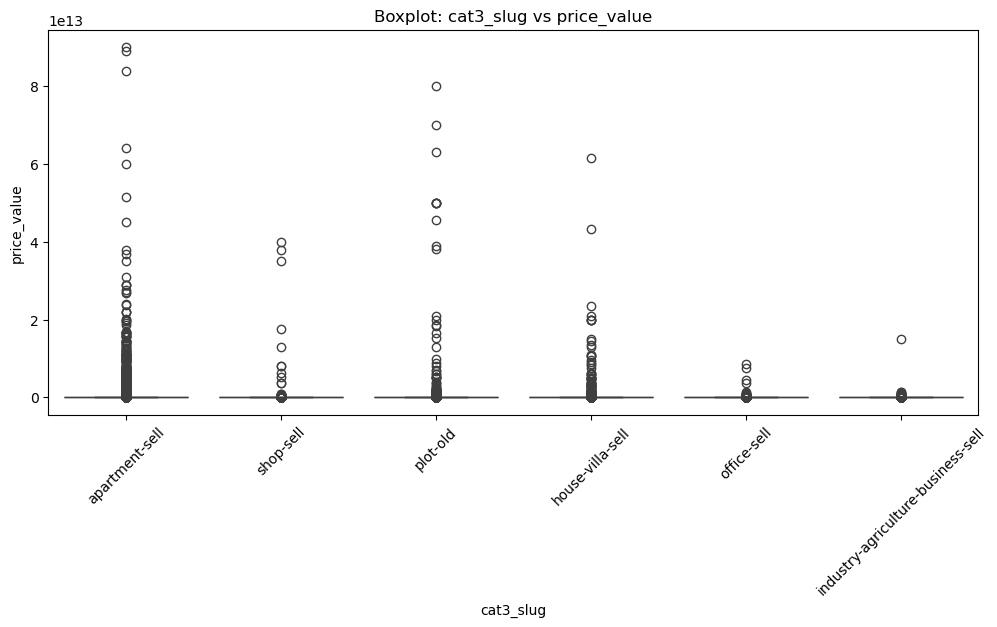

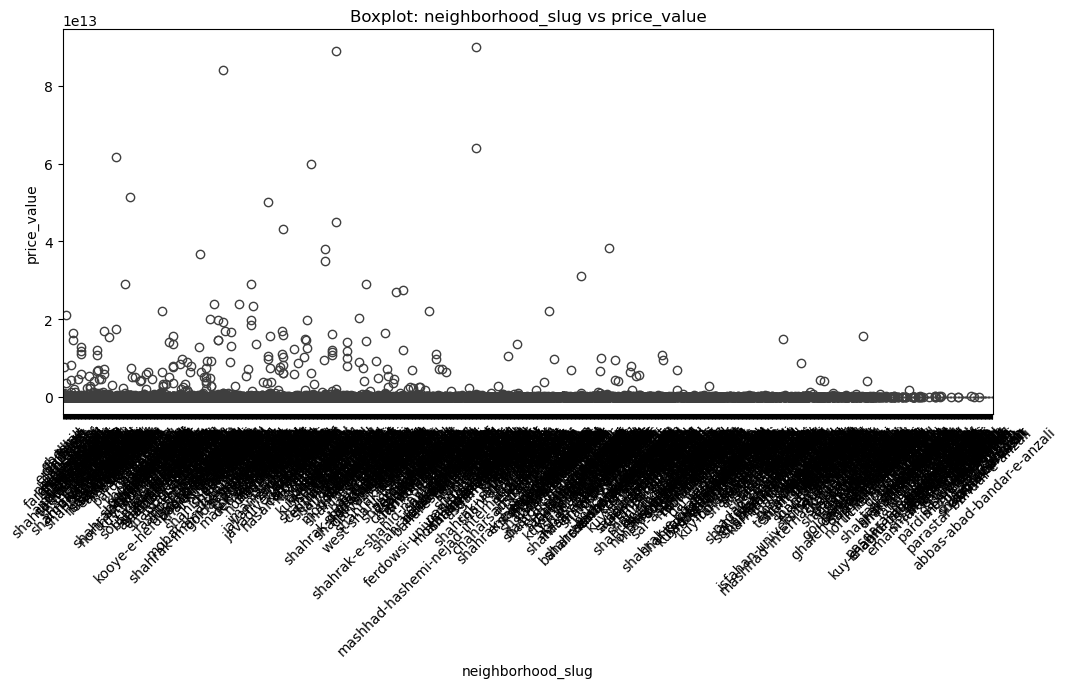

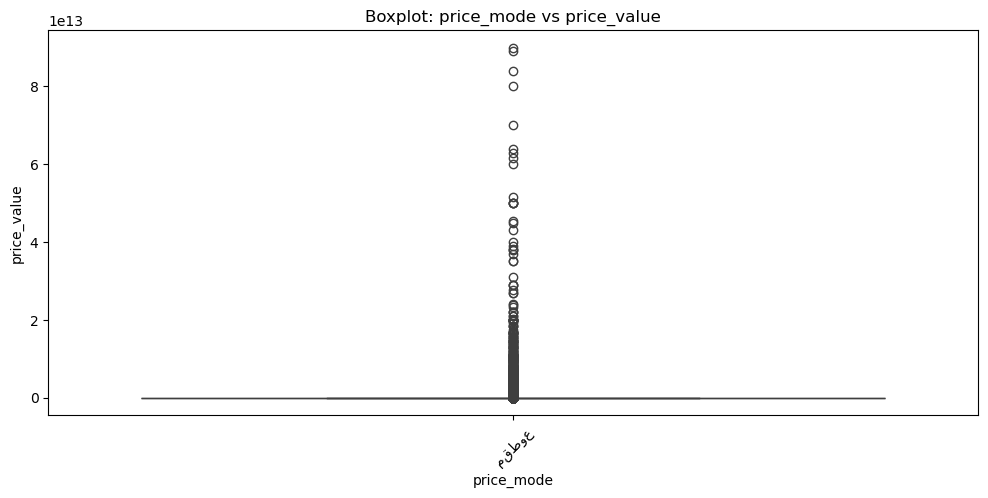

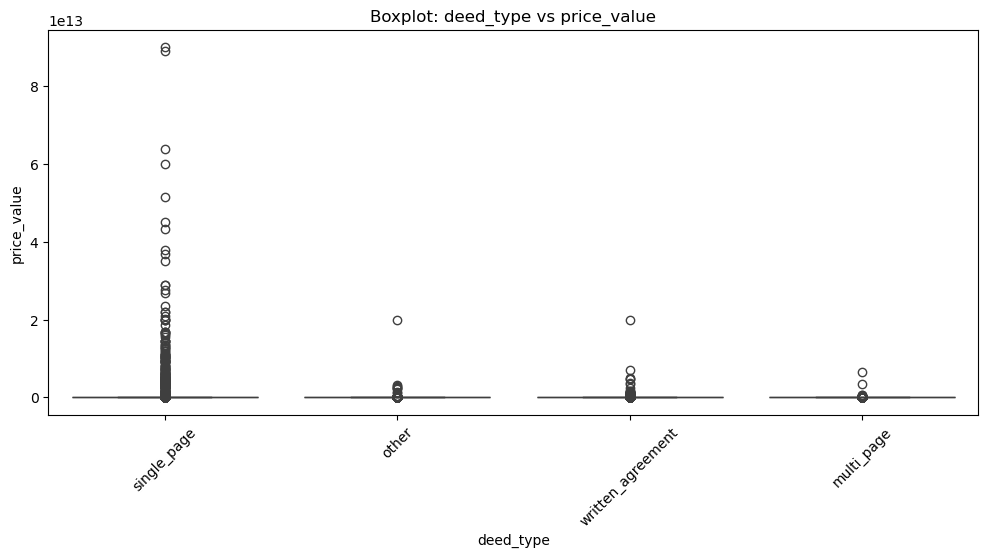

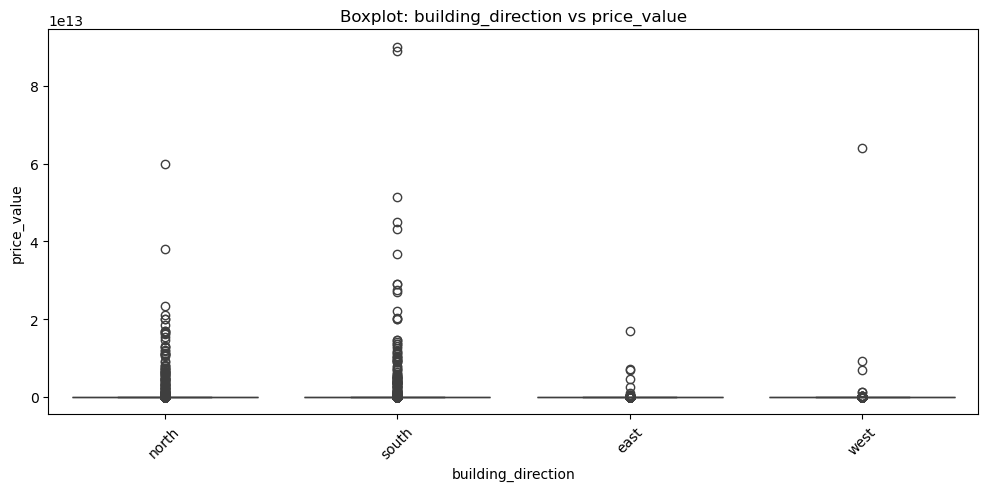

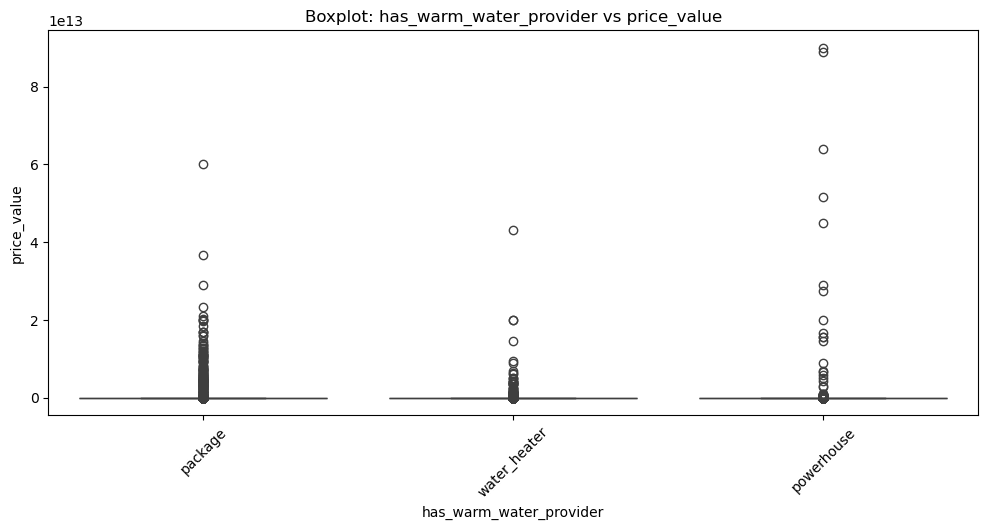

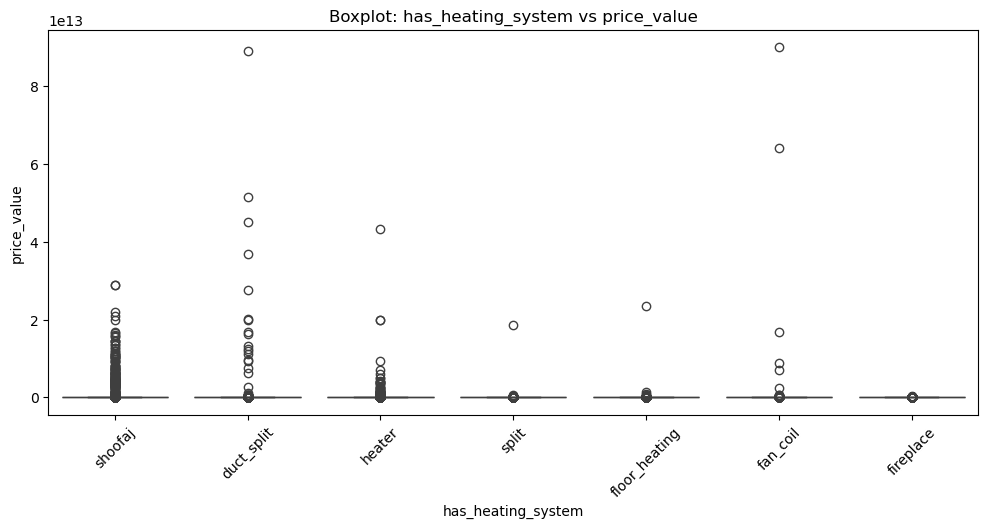

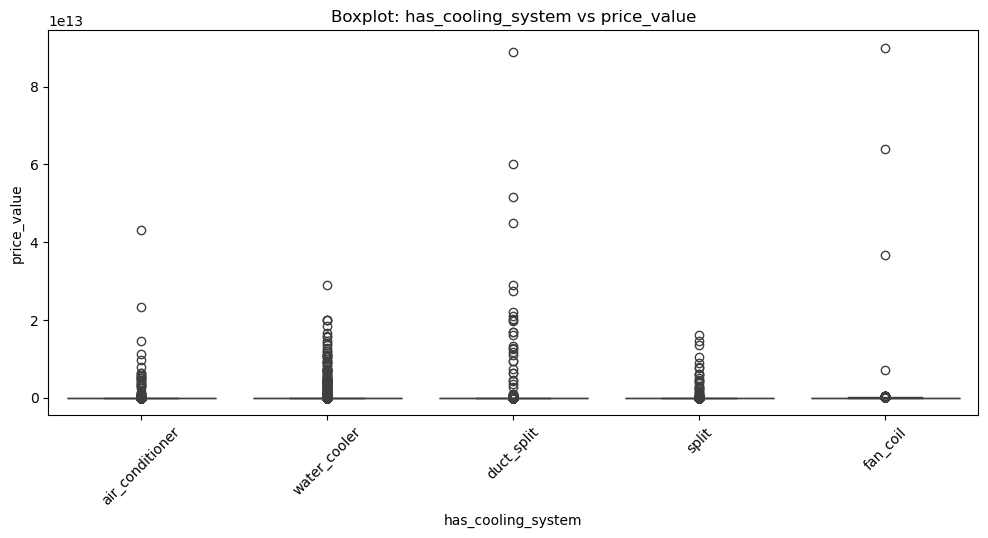

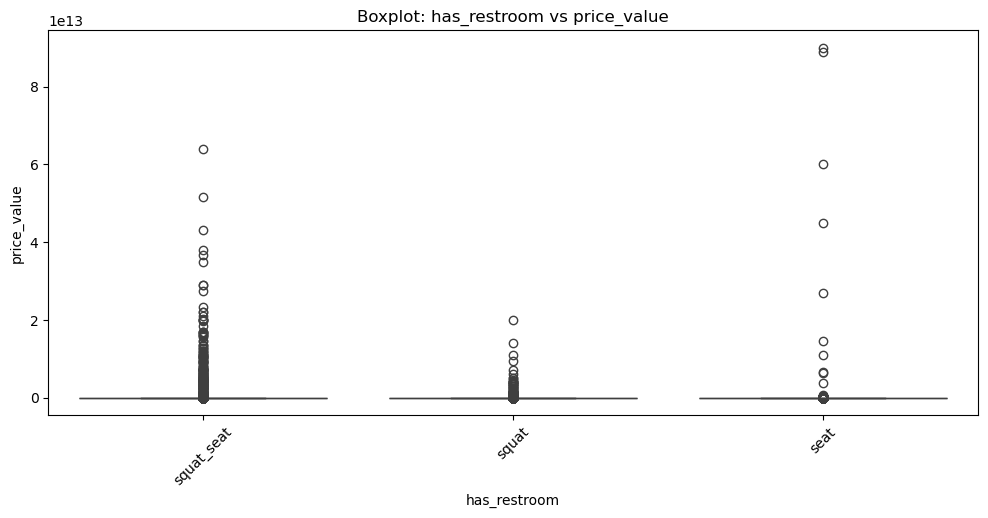

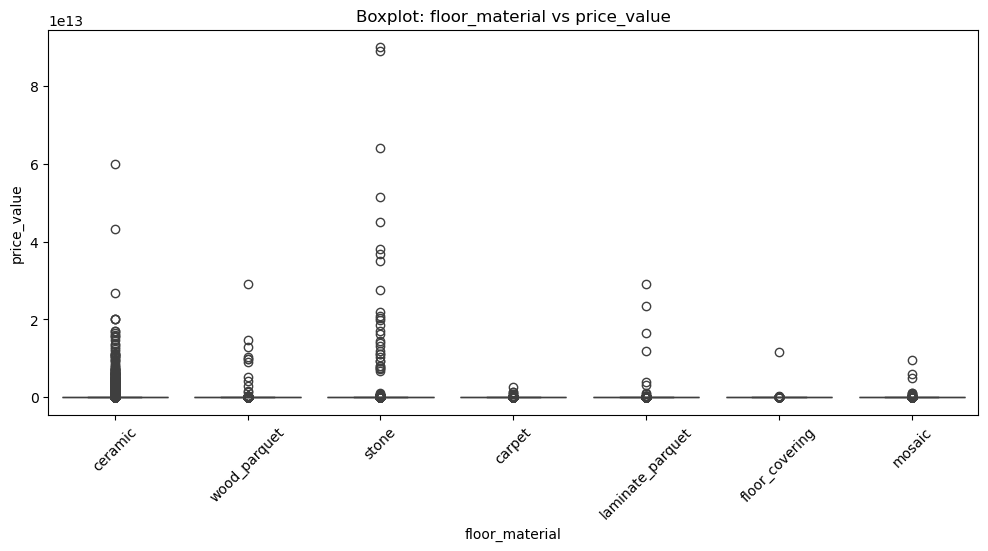

In [42]:

# -----------------------------
# ستون هدف
target_col = 'price_value'

# 1️⃣ تشخیص ستون‌های عددی و دسته‌ای
numeric_cols = df_sell.select_dtypes(include=['int64', 'float64', 'float32', 'Int64', 'int32']).columns.tolist()

categorical_cols = df_sell.select_dtypes(include=['object', 'category']).columns.tolist()

# دقت کن: numeric_cols شامل target_col هم هست
# numeric_cols = [col for col in numeric_cols if col != target_col]  # ❌ کامنت کنیم

# 2️⃣ محاسبه همبستگی ستون‌های عددی با target
corr_with_target = df_sell[numeric_cols].corr()[target_col]

# 3️⃣ انتخاب 10 ستون با بیشترین همبستگی (قدر مطلق)
top_numeric_cols = corr_with_target.abs().sort_values(ascending=False).head(15).index.tolist()

print("Top 15 numeric columns correlated with price_value:")
print(top_numeric_cols)

# 4️⃣ رسم scatterplot برای ستون‌های عددی
for col in top_numeric_cols:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=col, y=target_col, data=df_sell, alpha=0.5)
    plt.title(f'Scatter plot: {col} vs {target_col}')
    plt.show()

# 5️⃣ رسم boxplot برای ستون‌های دسته‌ای مهم
important_categorical_cols = ['cat2_slug', 'cat3_slug', 'neighborhood_slug','price_mode','deed_type','building_direction',
                              'has_warm_water_provider','has_heating_system','has_cooling_system','has_restroom','floor_material']

for col in important_categorical_cols:
    if col in df_sell.columns:
        plt.figure(figsize=(12,5))
        sns.boxplot(x=col, y=target_col, data=df_sell)
        plt.xticks(rotation=45)
        plt.title(f'Boxplot: {col} vs {target_col}')
        plt.show()


In [145]:
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import matplotlib.pyplot as plt

pdf = PdfPages("sell_plots2.pdf")   # output file

target_col = 'price_value'

numeric_cols = df_sell.select_dtypes(include=['number']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != target_col]

df_corr = df_sell[[target_col] + numeric_cols].corr()
corr_with_target = df_corr[target_col].drop(labels=[target_col])
top_numeric_cols = corr_with_target.abs().sort_values(ascending=False).head(15).index.tolist()

# Scatter plots
for col in top_numeric_cols:
    fig = plt.figure(figsize=(8,5))
    sns.scatterplot(x=col, y=target_col, data=df_sell, alpha=0.5)
    plt.title(f'{col} vs {target_col}')
    pdf.savefig(fig)  # save the figure
    plt.close(fig)

# Boxplots
important_categorical_cols = [
    'cat2_slug', 'cat3_slug', 'neighborhood_slug', 'price_mode',
    'deed_type', 'building_direction', 'has_warm_water_provider',
    'has_heating_system', 'has_cooling_system', 'has_restroom', 'floor_material'
]

for col in important_categorical_cols:
    if col in df_sell.columns:
        if df_sell[col].nunique() < 30:
            fig = plt.figure(figsize=(14,5))
            sns.boxplot(x=col, y=target_col, data=df_sell)
            plt.xticks(rotation=45)
            plt.title(f'{col} vs {target_col}')
            pdf.savefig(fig)
            plt.close(fig)

pdf.close()
print("PDF successfully saved!")


PDF successfully saved!


<Figure size 800x500 with 0 Axes>

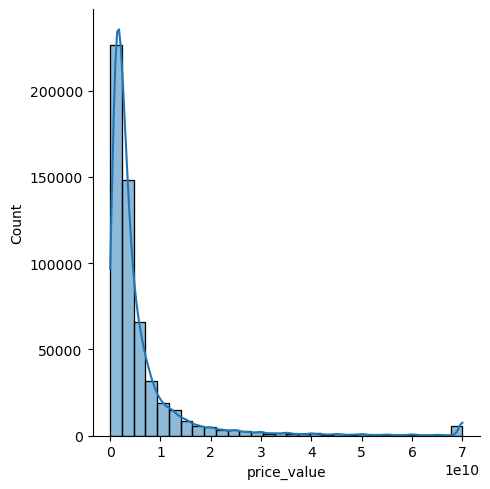

In [146]:
plt.figure(figsize=(8,5))
sns.displot(df_sell['price_value'] , bins=30 , kde=True )

In [86]:
df_rent.columns

Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_value', 'rent_to_single', 'rent_type', 'credit_mode',
       'credit_value', 'land_size', 'building_size', 'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'location_latitude',
       'location_longitude'],
      dtype='object')

In [ ]:

# -----------------------------
# ستون هدف
target_col = 'price_value'

# 1️⃣ تشخیص ستون‌های عددی و دسته‌ای
numeric_cols = df_sell.select_dtypes(include=['int64', 'float64', 'float32', 'Int64', 'int32']).columns.tolist()
categorical_cols = df_sell.select_dtypes(include=['object', 'category']).columns.tolist()

# دقت کن: numeric_cols شامل target_col هم هست
# numeric_cols = [col for col in numeric_cols if col != target_col]  # ❌ کامنت کنیم

# 2️⃣ محاسبه همبستگی ستون‌های عددی با target
corr_with_target = df_sell[numeric_cols].corr()[target_col]

# 3️⃣ انتخاب 10 ستون با بیشترین همبستگی (قدر مطلق)
top_numeric_cols = corr_with_target.abs().sort_values(ascending=False).head(15).index.tolist()

print("Top 15 numeric columns correlated with price_value:")
print(top_numeric_cols)

# 4️⃣ رسم scatterplot برای ستون‌های عددی
for col in top_numeric_cols:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=col, y=target_col, data=df_sell, alpha=0.5)
    plt.title(f'Scatter plot: {col} vs {target_col}')
    plt.show()

# 5️⃣ رسم boxplot برای ستون‌های دسته‌ای مهم
important_categorical_cols = ['cat2_slug', 'cat3_slug', 'neighborhood_slug','price_mode','deed_type','building_direction',
                              'has_warm_water_provider','has_heating_system','has_cooling_system','has_restroom','floor_material']

for col in important_categorical_cols:
    if col in df_sell.columns:
        plt.figure(figsize=(12,5))
        sns.boxplot(x=col, y=target_col, data=df_sell)
        plt.xticks(rotation=45)
        plt.title(f'Boxplot: {col} vs {target_col}')
        plt.show()


In [87]:
df_temp_rent.columns


Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'land_size',
       'building_size', 'floor', 'rooms_count', 'total_floors_count',
       'unit_per_floor', 'has_balcony', 'has_elevator', 'has_warehouse',
       'has_parking', 'construction_year', 'is_rebuilt', 'has_water',
       'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',
       'regular_person_capacity', 'extra_person_capacity',
       'cost_per_extra_person', 'rent_price_on_regular_days',
       'rent_price_on_special_days', 'rent_price_at_weekends',
       'location_latitude', 'location_longitude'],
      dtype='object')